# Probability Distribution Modeling cho bài toán Next-Time Prediction

Notebook này không dự đoán một thời điểm chính xác duy nhất cho sự kiện tiếp theo. Thay vào đó, ta dự đoán **một phân phối xác suất** trên các cửa sổ thời gian tương lai:

`P(0-1h), P(1-6h), P(6-24h), P(1-3d), P(3-7d), P(>7d)`

Cách nhìn này phù hợp hơn với timing recommendation: hệ thống có thể chọn cửa sổ có xác suất cao nhất, hoặc cửa sổ hữu ích nhất theo mục tiêu business/campaign, để quyết định khi nào nên trigger một hành động.

So sánh ngắn:

| Cách mô hình hóa | Đầu vào -> Đầu ra |
|---|---|
| Exact-time prediction | current context -> predicted `delta_t_seconds` |
| Time-bucket classification | current context -> one predicted bucket |
| Probability-distribution prediction | current context -> probability distribution over all future buckets |

Trong hướng nghiên cứu action-conditioned event timing prediction, item/action có thể được chọn bởi business rule, inventory priority, campaign objective, hoặc một recommender module riêng. Notebook này chỉ tập trung vào **timing layer**: với lịch sử user và ngữ cảnh sự kiện hiện tại, ước lượng phân phối xác suất khi nào sự kiện tiếp theo sẽ xảy ra.


## 1. Setup

Phần này import các thư viện nhẹ, thiết lập thư mục output riêng cho notebook này, và định nghĩa các bucket thời gian loại trừ lẫn nhau. Notebook đọc target parquet đã tạo từ feasibility notebook; chỉ khi các file đó thiếu thì mới cần quay lại notebook feasibility để tạo dữ liệu.


In [34]:
from pathlib import Path
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TARGET_SAMPLE_DIR = PROJECT_ROOT / "outputs" / "next_time_feasibility" / "target_samples"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "next_time_probability_distribution"
PROB_SAMPLE_DIR = OUTPUT_DIR / "probability_samples"
FIGURE_DIR = OUTPUT_DIR / "figures"

for path in [OUTPUT_DIR, PROB_SAMPLE_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TIME_BUCKETS = [
    ("0_1h", 0, 3600),
    ("1_6h", 3600, 6 * 3600),
    ("6_24h", 6 * 3600, 24 * 3600),
    ("1_3d", 24 * 3600, 3 * 24 * 3600),
    ("3_7d", 3 * 24 * 3600, 7 * 24 * 3600),
    ("gt_7d", 7 * 24 * 3600, np.inf),
]
BUCKET_ORDER = ["0_1h", "1_6h", "6_24h", "1_3d", "3_7d", "gt_7d"]
BUCKET_LABELS = BUCKET_ORDER
BUCKET_TO_INDEX = {bucket: idx for idx, bucket in enumerate(BUCKET_ORDER)}

# User-balanced sampling là mặc định cho clean rerun.
USE_USER_BALANCED_SAMPLING = True

SAMPLING_CONFIG = {
    "lastfm": {
        "max_users": 500,
        "max_events_per_user": 500,
        "min_events_per_user": 5,
    },
    "retailrocket": {
        "max_users": 30_000,
        "max_events_per_user": 50,
        "min_events_per_user": 3,
    },
    "taobao": {
        "max_users": 10_000,
        "max_events_per_user": 100,
        "min_events_per_user": 3,
    },
}

# Fallback cũ theo số dòng, chỉ dùng khi USE_USER_BALANCED_SAMPLING = False.
MAX_ROWS_PER_DATASET = {
    "lastfm": 300_000,
    "retailrocket": 300_000,
    "taobao": 300_000,
}

USE_RATE_FEATURES_FOR_ML = False
RUN_RANDOM_FOREST = False

SPLIT_STRATEGY = "temporal_ratio"
TEST_FRACTION_PER_USER = 0.2
MIN_TEST_EVENTS_PER_USER = 3
MAX_TEST_EVENTS_PER_USER = 20
MIN_TRAIN_EVENTS_PER_USER = 3

RANDOM_STATE = 42

print(f"Project root: {PROJECT_ROOT}")
print(f"Target sample directory: {TARGET_SAMPLE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Project root: y:\Recommender-System-Dashboard
Target sample directory: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples
Output directory: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution


### Ghi chú về sampling cho lần chạy sạch

Notebook dùng split theo thời gian trong từng user, nên số user và độ dài chuỗi sau sampling ảnh hưởng trực tiếp đến độ tin cậy của test set. Nếu chỉ sample theo số dòng, Last.fm có thể giữ lại rất ít user nặng vì một số user có lịch sử nghe rất dài; khi đó metric dễ bị chi phối bởi vài chuỗi cá biệt.

Vì vậy clean rerun dùng **user-balanced sampling**: sample user trước, lọc user có đủ số event tối thiểu, giới hạn số event tối đa trên mỗi user, và giữ nguyên thứ tự thời gian. Với user có lịch sử dài, notebook giữ các event mới nhất bằng `.tail(max_events_per_user)` để bảo toàn tính thực tế theo thời gian.

`MAX_ROWS_PER_DATASET` chỉ còn là fallback khi đặt `USE_USER_BALANCED_SAMPLING = False`.


In [35]:
def delta_to_distribution_bucket(delta_t_seconds) -> str | float:
    """Map một delta_t_seconds vào đúng một bucket loại trừ lẫn nhau."""
    if pd.isna(delta_t_seconds) or delta_t_seconds <= 0:
        return np.nan
    value = float(delta_t_seconds)
    for label, lower, upper in TIME_BUCKETS:
        if lower < value <= upper or (lower == 0 and 0 < value <= upper):
            return label
    return "gt_7d"


def add_time_bucket_distribution(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["time_bucket_distribution"] = df["delta_t_seconds"].map(delta_to_distribution_bucket)
    df["time_bucket_distribution"] = pd.Categorical(
        df["time_bucket_distribution"], categories=BUCKET_LABELS, ordered=True
    )
    return df


def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")


## 2. Load existing target samples

Notebook ưu tiên đọc các file parquet trong `outputs/next_time_feasibility/target_samples/`. Nếu một dataset không có file target sample, dataset đó được bỏ qua thay vì làm crash toàn bộ notebook.

Sau khi parse timestamp và lọc dòng không hợp lệ, notebook mặc định dùng user-balanced sampling: chọn đủ số user, giới hạn số event trên mỗi user, và giữ các event gần nhất để preserve temporal order. Cách này đặc biệt quan trọng với Last.fm vì lịch sử user có thể rất dài.


In [36]:
DATASET_PATTERNS = {
    "lastfm": ["*lastfm*target*.parquet", "*lastfm*.parquet"],
    "retailrocket": ["*retailrocket*target*.parquet", "*retailrocket*.parquet"],
    "taobao": ["*taobao*target*.parquet", "*taobao*.parquet"],
}
REQUIRED_COLUMNS = ["user_id", "item_id", "event_type", "timestamp", "delta_t_seconds"]
OPTIONAL_COLUMNS = ["dataset", "data_scope", "category_id", "next_timestamp", "time_bucket"]
load_sampling_summary_rows = []


def discover_target_files(target_dir: Path = TARGET_SAMPLE_DIR) -> dict[str, Path]:
    discovered = {}
    if not target_dir.exists():
        print(f"Target sample directory does not exist: {target_dir}")
        return discovered
    for dataset, patterns in DATASET_PATTERNS.items():
        matches = []
        for pattern in patterns:
            matches.extend(sorted(target_dir.glob(pattern)))
        if matches:
            discovered[dataset] = matches[0]
    return discovered


def parquet_columns(file_path: Path) -> list[str]:
    try:
        import pyarrow.parquet as pq

        return pq.ParquetFile(file_path).schema.names
    except Exception:
        return pd.read_parquet(file_path).columns.tolist()


def sample_users_balanced(
    df: pd.DataFrame,
    dataset: str,
    config: dict,
    random_state: int = 42,
) -> pd.DataFrame:
    cfg = config.get(dataset, {})
    max_users = cfg.get("max_users")
    max_events_per_user = cfg.get("max_events_per_user")
    min_events_per_user = cfg.get("min_events_per_user", 2)

    df = df.sort_values(["user_id", "timestamp"]).copy()
    user_counts = df["user_id"].value_counts()
    eligible_users = user_counts[user_counts >= min_events_per_user].index.to_numpy()

    rng = np.random.default_rng(random_state)
    if max_users is not None and len(eligible_users) > max_users:
        eligible_users = rng.choice(eligible_users, size=max_users, replace=False)

    sampled = df[df["user_id"].isin(eligible_users)].copy()

    if max_events_per_user is not None:
        sampled = (
            sampled.sort_values(["user_id", "timestamp"])
            .groupby("user_id", group_keys=False)
            .tail(max_events_per_user)
            .copy()
        )

    return sampled.sort_values(["user_id", "timestamp"]).copy()


def sample_rows_fallback(df: pd.DataFrame, max_rows: int | None = None) -> pd.DataFrame:
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    rng = np.random.default_rng(RANDOM_STATE)
    users = df["user_id"].dropna().unique()
    sampled_users = rng.permutation(users)
    selected = []
    total = 0
    counts = df["user_id"].value_counts()
    for user in sampled_users:
        selected.append(user)
        total += int(counts.loc[user])
        if total >= max_rows:
            break
    return df[df["user_id"].isin(selected)].copy()


def read_target_sample(dataset: str, file_path: Path, max_rows: int | None = None) -> pd.DataFrame:
    available_cols = parquet_columns(file_path)
    read_cols = [col for col in OPTIONAL_COLUMNS + REQUIRED_COLUMNS if col in available_cols]
    missing = [col for col in REQUIRED_COLUMNS if col not in available_cols]
    if missing:
        raise ValueError(f"{file_path.name} missing required columns: {missing}")

    df = pd.read_parquet(file_path, columns=read_cols)
    df["dataset"] = dataset
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    if "next_timestamp" in df.columns:
        df["next_timestamp"] = pd.to_datetime(df["next_timestamp"], errors="coerce", utc=True)

    before_filtering = len(df)
    df = df.dropna(subset=["user_id", "timestamp", "delta_t_seconds"])
    df = df[df["delta_t_seconds"] > 0].copy()
    dropped_invalid = before_filtering - len(df)

    original_rows_before_sampling = len(df)
    original_users_before_sampling = df["user_id"].nunique()

    if USE_USER_BALANCED_SAMPLING:
        df = sample_users_balanced(
            df=df,
            dataset=dataset,
            config=SAMPLING_CONFIG,
            random_state=RANDOM_STATE,
        )
    else:
        df = sample_rows_fallback(df, max_rows=max_rows)

    user_counts_after = df["user_id"].value_counts()
    cfg = SAMPLING_CONFIG.get(dataset, {})
    load_sampling_summary_rows.append(
        {
            "dataset": dataset,
            "original_rows_before_sampling": int(original_rows_before_sampling),
            "rows_after_sampling": int(len(df)),
            "users_before_sampling": int(original_users_before_sampling),
            "users_after_sampling": int(df["user_id"].nunique()),
            "median_events_per_user_after_sampling": float(user_counts_after.median()) if len(user_counts_after) else 0.0,
            "max_events_per_user_after_sampling": int(user_counts_after.max()) if len(user_counts_after) else 0,
            "min_events_per_user_config": cfg.get("min_events_per_user"),
            "max_users_config": cfg.get("max_users"),
            "max_events_per_user_config": cfg.get("max_events_per_user"),
        }
    )

    print(
        f"Loaded {dataset}: {len(df):,} rows / {df['user_id'].nunique():,} users "
        f"from {file_path.name} after sampling (dropped invalid rows: {dropped_invalid:,})"
    )
    return df


found_files = discover_target_files()
print("Found target sample files:")
for dataset, path in found_files.items():
    print(f"- {dataset}: {path}")

samples = {}
for dataset, path in found_files.items():
    samples[dataset] = read_target_sample(dataset, path, MAX_ROWS_PER_DATASET.get(dataset))

if not samples:
    raise FileNotFoundError(
        f"No target sample parquet files found under {TARGET_SAMPLE_DIR}. "
        "Run notebooks/next_time_dataset_feasibility.ipynb first."
    )

load_sampling_summary_df = pd.DataFrame(load_sampling_summary_rows)
save_csv(load_sampling_summary_df, OUTPUT_DIR / "load_sampling_summary.csv")
display(load_sampling_summary_df)


Found target sample files:
- lastfm: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\lastfm_next_time_targets.parquet
- retailrocket: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\retailrocket_next_time_targets.parquet
- taobao: y:\Recommender-System-Dashboard\outputs\next_time_feasibility\target_samples\taobao_next_time_targets.parquet
Loaded lastfm: 242,004 rows / 500 users from lastfm_next_time_targets.parquet after sampling (dropped invalid rows: 0)
Loaded retailrocket: 207,405 rows / 30,000 users from retailrocket_next_time_targets.parquet after sampling (dropped invalid rows: 0)
Loaded taobao: 677,164 rows / 10,000 users from taobao_next_time_targets.parquet after sampling (dropped invalid rows: 0)
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\load_sampling_summary.csv


,dataset,original_rows_before_sampling,rows_after_sampling,users_before_sampling,users_after_sampling,median_events_per_user_after_sampling,max_events_per_user_after_sampling,min_events_per_user_config,max_users_config,max_events_per_user_config
0,lastfm,19055618,242004,992,500,500.0,500,5,500,500
1,retailrocket,1345435,207405,405966,30000,4.0,50,3,30000,50
2,taobao,5020662,677164,49996,10000,74.5,100,3,10000,100


### Nhận xét về quá trình sampling

Bảng trên tóm tắt sự thay đổi kích thước dữ liệu sau khi áp dụng user-balanced sampling. Mục tiêu của bước này là tránh việc một số user có lịch sử quá dài chi phối toàn bộ tập mẫu, đồng thời đảm bảo mỗi dataset có đủ số lượng user để đánh giá bằng temporal ratio split.

Đối với **Last.fm**, dữ liệu gốc có hơn 19 triệu sample next-time từ 992 user. Sau sampling, notebook giữ lại 500 user và tối đa 500 event gần nhất cho mỗi user, tạo ra 242,004 dòng dữ liệu. Điều này khắc phục vấn đề của row-based sampling trước đó, khi một vài heavy users có thể chiếm phần lớn số dòng và khiến test set chỉ còn rất ít user. Vì leave-last-one-out tạo một dòng test cho mỗi user, việc tăng số user sau sampling giúp kết quả đánh giá Last.fm đáng tin hơn.

Đối với **RetailRocket**, dữ liệu ban đầu có hơn 1.34 triệu sample nhưng rất thưa theo user, với hơn 405 nghìn user. Sau sampling, notebook giữ lại 30,000 user và 207,405 dòng. Median event per user sau sampling chỉ là 4, cho thấy phần lớn user có lịch sử rất ngắn. Vì vậy, RetailRocket có test set lớn nhưng tín hiệu lịch sử cá nhân hóa có thể yếu; kết quả mô hình có khả năng phụ thuộc nhiều vào các prior đơn giản như `event_type`, item popularity hoặc global bucket distribution.

Đối với **Taobao**, sau sampling còn 10,000 user và 677,164 dòng, với median event per user là 74.5. Đây là dataset cân bằng nhất trong ba tập dữ liệu vì vừa có số user đủ lớn, vừa có lịch sử tương tác tương đối dài cho mỗi user. Do đó, Taobao là dataset phù hợp nhất để kiểm tra liệu mô hình có học được temporal pattern từ lịch sử hành vi hay không.

Nhìn chung, cấu hình sampling hiện tại phù hợp hơn cho đánh giá next-time probability distribution so với giới hạn số dòng đơn thuần. Last.fm được xử lý tốt hơn nhờ giới hạn số event mỗi user; RetailRocket phản ánh đúng đặc trưng sparse của dữ liệu thương mại điện tử; còn Taobao cung cấp điều kiện tốt nhất để đánh giá khả năng học tín hiệu thời gian của mô hình.

## 3. Tạo target xác suất dạng phân phối

Target `time_bucket_distribution` biểu diễn một phân phối rời rạc trên các cửa sổ thời gian có thể xảy ra trong tương lai. Khác với cumulative horizon labels, các bucket này **loại trừ lẫn nhau**, nên classifier có thể xuất ra một vector xác suất chuẩn hóa trên toàn bộ bucket.


In [37]:
distribution_rows = []
probability_samples = {}

for dataset, df in samples.items():
    df = add_time_bucket_distribution(df)
    df = df.dropna(subset=["time_bucket_distribution"]).copy()
    probability_samples[dataset] = df

    counts = df["time_bucket_distribution"].value_counts(sort=False).reindex(BUCKET_LABELS, fill_value=0)
    percentages = counts / counts.sum() * 100
    for bucket in BUCKET_LABELS:
        distribution_rows.append(
            {
                "dataset": dataset,
                "bucket": bucket,
                "count": int(counts.loc[bucket]),
                "percentage": float(percentages.loc[bucket]),
            }
        )

    out_path = PROB_SAMPLE_DIR / f"{dataset}_probability_distribution_samples.parquet"
    save_parquet(df, out_path)

time_bucket_distribution_df = pd.DataFrame(distribution_rows)
save_csv(time_bucket_distribution_df, OUTPUT_DIR / "time_bucket_distribution.csv")
display(time_bucket_distribution_df)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\probability_samples\lastfm_probability_distribution_samples.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\probability_samples\retailrocket_probability_distribution_samples.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\probability_samples\taobao_probability_distribution_samples.parquet
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\time_bucket_distribution.csv


,dataset,bucket,count,percentage
0,lastfm,0_1h,225828,93.315813
1,lastfm,1_6h,4961,2.049966
2,lastfm,6_24h,5853,2.418555
3,lastfm,1_3d,2864,1.183452
4,lastfm,3_7d,1319,0.545032
5,lastfm,gt_7d,1179,0.487182
6,retailrocket,0_1h,158658,76.496709
7,retailrocket,1_6h,10042,4.841735
8,retailrocket,6_24h,11076,5.340276
9,retailrocket,1_3d,8680,4.185049


### Nhận xét về phân phối time bucket

Bảng trên cho thấy phân phối target `time_bucket_distribution` bị lệch mạnh về các khoảng thời gian ngắn, đặc biệt là bucket `0_1h`. Điều này có nghĩa là phần lớn các event tiếp theo xảy ra trong vòng một giờ sau event hiện tại. Vì vậy, bài toán probability distribution prediction trong notebook này không phải là một bài toán multiclass cân bằng, mà là một bài toán dự đoán phân phối thời gian có class imbalance rất rõ rệt.

Đối với **Last.fm**, bucket `0_1h` chiếm hơn 93% tổng số sample. Điều này phản ánh đặc trưng của dữ liệu nghe nhạc: các lượt nghe thường xuất hiện liên tiếp trong cùng một session, khiến thời gian giữa hai event gần nhau rất ngắn. Các bucket dài hơn như `3_7d` và `gt_7d` chỉ chiếm dưới 1%, nên mô hình rất dễ học xu hướng dự đoán về bucket ngắn nhất. Do đó, accuracy cao trên Last.fm chưa chắc phản ánh khả năng dự đoán timing tốt ở mọi khoảng thời gian.

Đối với **RetailRocket**, bucket `0_1h` chiếm khoảng 76.5%, thấp hơn Last.fm và Taobao. Các bucket còn lại có tỷ lệ từ khoảng 3% đến 6%, bao gồm cả `gt_7d` với khoảng 6%. Đây là phân phối cân bằng hơn tương đối so với hai dataset còn lại, nên RetailRocket phù hợp để kiểm tra liệu mô hình có phân biệt được các khoảng thời gian ngắn, trung bình và dài hay không. Tuy nhiên, dữ liệu RetailRocket lại sparse theo user, nên tín hiệu lịch sử cá nhân hóa vẫn có thể yếu.

Đối với **Taobao**, bucket `0_1h` chiếm khoảng 84.2%, trong khi `gt_7d` gần như không xuất hiện, chỉ chiếm khoảng 0.002%. Điều này cho thấy trong tập mẫu hiện tại, hành vi người dùng trên Taobao có xu hướng diễn ra dày trong các khoảng ngắn, còn các khoảng rất dài gần như không đủ dữ liệu để học. Vì vậy, các metric theo class như macro-F1, balanced accuracy và per-class recall là rất quan trọng để tránh kết luận sai từ accuracy tổng thể.

Nhìn chung, cả ba dataset đều có phân phối target lệch về bucket ngắn, nhưng mức độ lệch khác nhau. Last.fm lệch mạnh nhất do tính chất session-based của hành vi nghe nhạc; Taobao cũng lệch mạnh nhưng vẫn có nhiều lịch sử theo user; RetailRocket có phân phối bucket đa dạng hơn nhưng user history ngắn hơn. Vì vậy, khi đánh giá mô hình, cần ưu tiên các metric như log loss, balanced accuracy, macro-F1, bucket distance và per-class performance thay vì chỉ dựa vào accuracy.

## Temporal split theo từng user

Notebook trước đó sử dụng leave-last-one-out, tức là mỗi user chỉ đóng góp một event cuối cùng vào test set. Cách này phù hợp với một số bài toán recommender ranking, nhưng trong bài toán next-time probability distribution, event cuối cùng của user có thể là điểm kết thúc quan sát hoặc chứa khoảng nghỉ dài bất thường. Điều này làm cho phân phối test khác biệt mạnh so với train, đặc biệt trên Last.fm.

Vì vậy, notebook này sử dụng temporal ratio split theo từng user. Với mỗi user, các event được sắp xếp theo thời gian; phần đầu chuỗi được dùng cho train và một phần cuối chuỗi được dùng cho test. Cách split này vẫn giữ đúng thứ tự thời gian, tránh leakage từ tương lai về quá khứ, nhưng tạo nhiều test sample hơn cho mỗi user và giảm ảnh hưởng của một event cuối cùng quá cực đoan.

Có thể đặt `SPLIT_STRATEGY = "leave_last_one"` để quay lại chiến lược cũ khi cần so sánh ablation.


In [38]:
def leave_last_one_out_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = df.sort_values(["user_id", "timestamp"]).copy()
    user_size = df.groupby("user_id")["timestamp"].transform("size")
    df = df[user_size >= 2].copy()
    df["_row_number"] = df.groupby("user_id").cumcount()
    df["_user_size"] = df.groupby("user_id")["timestamp"].transform("size")

    test_mask = df["_row_number"] == df["_user_size"] - 1
    train_df = df.loc[~test_mask].drop(columns=["_row_number", "_user_size"]).copy()
    test_df = df.loc[test_mask].drop(columns=["_row_number", "_user_size"]).copy()
    return train_df, test_df


def temporal_ratio_split_per_user(
    df: pd.DataFrame,
    user_col: str = "user_id",
    time_col: str = "timestamp",
    test_fraction: float = 0.2,
    min_test_events: int = 3,
    max_test_events: int = 20,
    min_train_events: int = 3,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_parts = []
    test_parts = []

    df = df.sort_values([user_col, time_col]).copy()

    for _, group in df.groupby(user_col, sort=False):
        group = group.sort_values(time_col).copy()
        n = len(group)

        if n < min_train_events + min_test_events:
            continue

        test_size = int(np.ceil(n * test_fraction))
        test_size = max(test_size, min_test_events)
        test_size = min(test_size, max_test_events)

        if n - test_size < min_train_events:
            test_size = n - min_train_events

        if test_size <= 0:
            continue

        train_parts.append(group.iloc[:-test_size])
        test_parts.append(group.iloc[-test_size:])

    train_df = pd.concat(train_parts, ignore_index=True) if train_parts else pd.DataFrame()
    test_df = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame()
    return train_df, test_df


def split_dataset_temporally(df: pd.DataFrame, dataset: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    if SPLIT_STRATEGY == "leave_last_one":
        return leave_last_one_out_split(df)
    if SPLIT_STRATEGY == "temporal_ratio":
        return temporal_ratio_split_per_user(
            df,
            user_col="user_id",
            time_col="timestamp",
            test_fraction=TEST_FRACTION_PER_USER,
            min_test_events=MIN_TEST_EVENTS_PER_USER,
            max_test_events=MAX_TEST_EVENTS_PER_USER,
            min_train_events=MIN_TRAIN_EVENTS_PER_USER,
        )
    raise ValueError(f"Unknown SPLIT_STRATEGY: {SPLIT_STRATEGY}")


def summarize_temporal_split(dataset: str, train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    train_users = set(train_df["user_id"].unique()) if len(train_df) else set()
    test_users = set(test_df["user_id"].unique()) if len(test_df) else set()
    test_events_per_user = test_df.groupby("user_id").size() if len(test_df) else pd.Series(dtype=float)
    return {
        "dataset": dataset,
        "split_strategy": SPLIT_STRATEGY,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "train_users": train_df["user_id"].nunique() if len(train_df) else 0,
        "test_users": test_df["user_id"].nunique() if len(test_df) else 0,
        "train_bucket_classes": train_df["time_bucket_distribution"].nunique() if len(train_df) else 0,
        "test_bucket_classes": test_df["time_bucket_distribution"].nunique() if len(test_df) else 0,
        "avg_test_events_per_user": float(test_events_per_user.mean()) if len(test_events_per_user) else 0.0,
        "median_test_events_per_user": float(test_events_per_user.median()) if len(test_events_per_user) else 0.0,
        "max_test_events_per_user": int(test_events_per_user.max()) if len(test_events_per_user) else 0,
        "pct_test_users_seen_in_train": 100 * len(test_users & train_users) / max(len(test_users), 1),
    }


split_data = {}
split_summary_rows = []

for dataset, df in probability_samples.items():
    train_df, test_df = split_dataset_temporally(df, dataset)
    split_data[dataset] = {"train": train_df, "test": test_df}
    split_summary_rows.append(summarize_temporal_split(dataset, train_df, test_df))

split_summary_df = pd.DataFrame(split_summary_rows)
save_csv(split_summary_df, OUTPUT_DIR / "split_summary.csv")
display(split_summary_df)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\split_summary.csv


,dataset,split_strategy,train_rows,test_rows,train_users,test_users,train_bucket_classes,test_bucket_classes,avg_test_events_per_user,median_test_events_per_user,max_test_events_per_user,pct_test_users_seen_in_train
0,lastfm,temporal_ratio,232081,9913,498,498,6,6,19.905622,20.0,20,100.0
1,retailrocket,temporal_ratio,97933,39908,11104,11104,6,6,3.594020,3.0,10,100.0
2,taobao,temporal_ratio,538798,138134,9945,9945,6,5,13.889794,15.0,20,100.0


## Kiểm tra độ tin cậy của split

Với temporal ratio split, số dòng test kỳ vọng lớn hơn nhiều so với leave-last-one-out vì mỗi user có thể đóng góp nhiều event cuối chuỗi. Notebook vẫn kiểm tra rõ `test_rows`, `test_users`, và số class xuất hiện trong test trước khi diễn giải metric mô hình.


In [39]:
MIN_TEST_USERS = 300
MIN_TEST_ROWS = 300
MIN_CLASSES_IN_TEST = 3


def check_split_reliability(dataset: str, train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
    warnings = []

    if test_df["user_id"].nunique() < MIN_TEST_USERS:
        warnings.append(f"test_users < {MIN_TEST_USERS}")

    if len(test_df) < MIN_TEST_ROWS:
        warnings.append(f"test_rows < {MIN_TEST_ROWS}")

    if test_df["time_bucket_distribution"].nunique() < MIN_CLASSES_IN_TEST:
        warnings.append(f"test classes < {MIN_CLASSES_IN_TEST}")

    return {
        "dataset": dataset,
        "split_strategy": SPLIT_STRATEGY,
        "test_rows": len(test_df),
        "test_users": test_df["user_id"].nunique(),
        "test_classes": test_df["time_bucket_distribution"].nunique(),
        "is_reliable": len(warnings) == 0,
        "warnings": "; ".join(warnings),
    }


split_reliability_df = pd.DataFrame(
    [
        check_split_reliability(dataset, parts["train"], parts["test"])
        for dataset, parts in split_data.items()
    ]
)

save_csv(split_reliability_df, OUTPUT_DIR / "split_reliability.csv")
display(split_reliability_df)


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\split_reliability.csv


,dataset,split_strategy,test_rows,test_users,test_classes,is_reliable,warnings
0,lastfm,temporal_ratio,9913,498,6,True,
1,retailrocket,temporal_ratio,39908,11104,6,True,
2,taobao,temporal_ratio,138134,9945,5,True,


## So sánh phân phối bucket giữa train và test

Biểu đồ grouped bar chart dưới đây kiểm tra temporal ratio split có làm giảm distribution shift giữa train và test hay không. Nếu phân phối test vẫn lệch nhiều so với train, metric cần được diễn giải như một bài toán dự đoán phần cuối chuỗi user khó hơn, chứ không phải lỗi do random split.


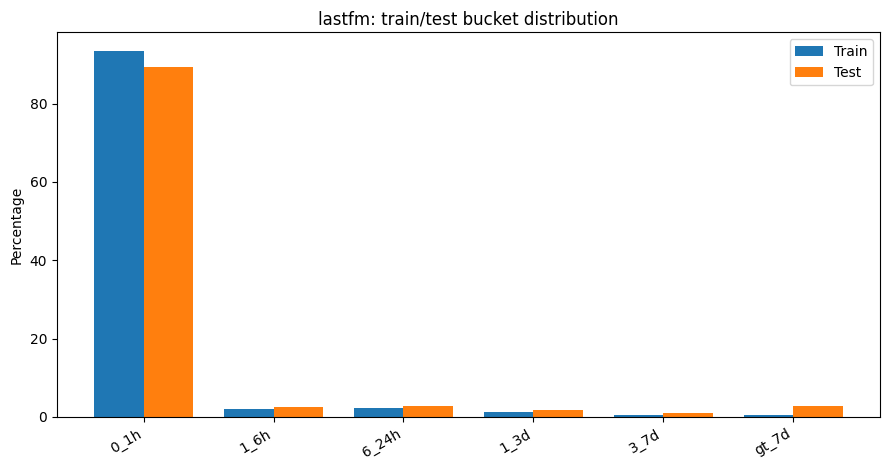

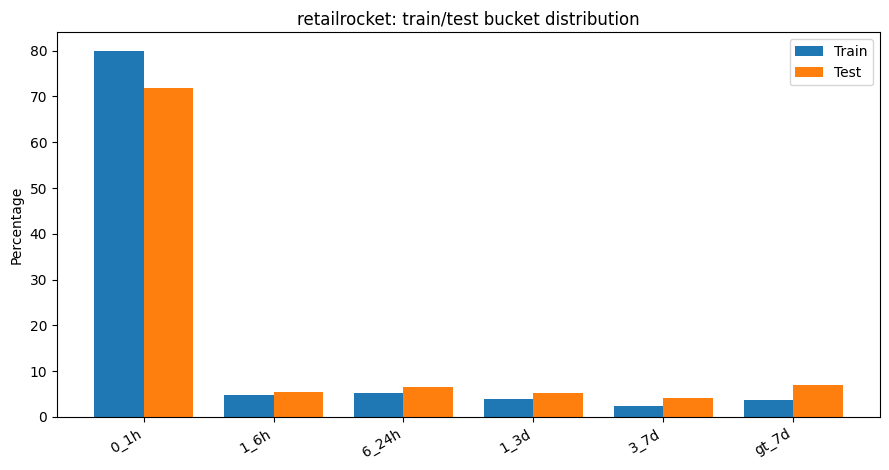

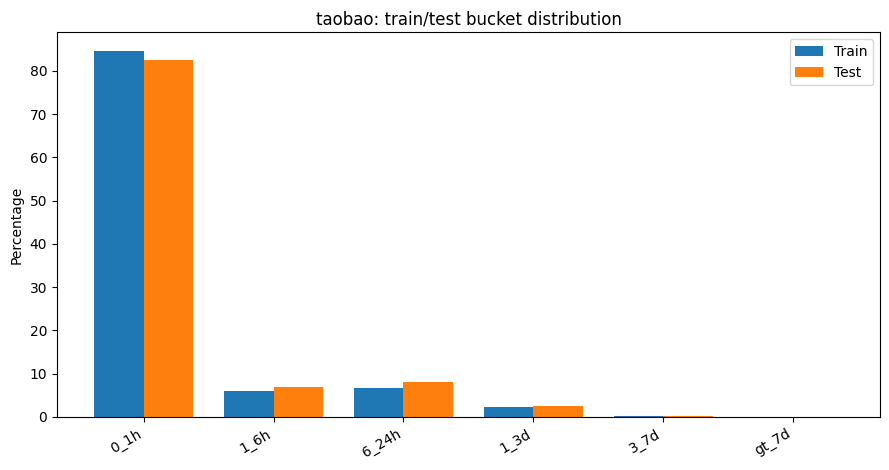

Saved train/test distribution figures:
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\lastfm_train_test_bucket_distribution.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\retailrocket_train_test_bucket_distribution.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\taobao_train_test_bucket_distribution.png


In [40]:
def plot_train_test_bucket_distribution(dataset: str, train_df: pd.DataFrame, test_df: pd.DataFrame) -> Path:
    train_counts = train_df["time_bucket_distribution"].value_counts(sort=False).reindex(BUCKET_ORDER, fill_value=0)
    test_counts = test_df["time_bucket_distribution"].value_counts(sort=False).reindex(BUCKET_ORDER, fill_value=0)
    train_pct = train_counts / max(train_counts.sum(), 1) * 100
    test_pct = test_counts / max(test_counts.sum(), 1) * 100

    x = np.arange(len(BUCKET_ORDER))
    width = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(x - width / 2, train_pct.to_numpy(), width=width, label="Train")
    ax.bar(x + width / 2, test_pct.to_numpy(), width=width, label="Test")
    ax.set_xticks(x, BUCKET_ORDER, rotation=30, ha="right")
    ax.set_ylabel("Percentage")
    ax.set_title(f"{dataset}: train/test bucket distribution")
    ax.legend()
    fig.tight_layout()

    path = FIGURE_DIR / f"{dataset}_train_test_bucket_distribution.png"
    fig.savefig(path, dpi=150)
    plt.show()
    return path

train_test_distribution_figures = []
for dataset, parts in split_data.items():
    train_test_distribution_figures.append(
        plot_train_test_bucket_distribution(dataset, parts["train"], parts["test"])
    )

print("Saved train/test distribution figures:")
for path in train_test_distribution_figures:
    print(path)


### Nhận xét về phân phối train/test sau temporal ratio split

Các biểu đồ trên cho thấy temporal ratio split giúp phân phối train và test ổn định hơn so với leave-last-one-out. Thay vì chỉ lấy một event cuối cùng của mỗi user làm test, split mới lấy một phần cuối chuỗi theo thời gian, nhờ đó test set không còn bị chi phối quá mạnh bởi một transition cuối cùng có thể mang tính cực đoan hoặc tương ứng với điểm kết thúc quan sát.

Đối với **Last.fm**, sự cải thiện rõ rệt nhất nằm ở việc bucket `gt_7d` trong test không còn tăng bất thường như trước. Cả train và test đều vẫn tập trung chủ yếu ở bucket `0_1h`, phản ánh đặc trưng session-based của dữ liệu nghe nhạc, nơi nhiều lượt nghe xảy ra liên tiếp trong thời gian ngắn. Điều này cho thấy split mới tạo ra test set đại diện hơn cho phân phối event-time thực tế của tập mẫu.

Đối với **RetailRocket**, test set vẫn có tỷ lệ `0_1h` thấp hơn train và tỷ lệ các bucket dài cao hơn. Tuy nhiên, mức lệch này không quá cực đoan và có thể phản ánh đúng đặc trưng của dữ liệu thương mại điện tử, nơi user có lịch sử ngắn và khoảng cách giữa các lần quay lại có thể biến động mạnh.

Đối với **Taobao**, phân phối train/test tương đối gần nhau. Test có xu hướng giảm nhẹ ở bucket `0_1h` và tăng ở các bucket trung bình như `1_6h`, `6_24h` và `1_3d`, nhưng gần như không có sự dịch chuyển lớn sang các bucket rất dài. Điều này khiến Taobao trở thành dataset phù hợp để đánh giá khả năng học timing pattern của mô hình.

Nhìn chung, temporal ratio split là lựa chọn phù hợp hơn cho notebook probability-distribution modeling. Cách split này vẫn giữ thứ tự thời gian, tránh leakage từ tương lai về quá khứ, đồng thời tạo test set ổn định và đáng tin hơn so với leave-last-one-out.

## 5. Feature engineering không rò rỉ target

Các feature cơ bản chỉ dùng thông tin hiện tại hoặc quá khứ trong chuỗi timestamp. Những feature aggregate theo bucket được tính **sau split** và chỉ fit trên train, sau đó map sang test với fallback là global train bucket distribution.


In [41]:
BASE_CATEGORICAL_FEATURES = [
    "event_type",
    "user_most_frequent_bucket",
    "item_most_frequent_bucket",
    "event_type_most_frequent_bucket",
]
BASE_NUMERIC_FEATURES = [
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "user_event_count_so_far",
    "item_event_count_so_far",
    "time_since_user_prev_event",
    "time_since_item_prev_event",
]
RATE_FEATURES = (
    [f"user_bucket_rate_{bucket}" for bucket in BUCKET_LABELS]
    + [f"item_bucket_rate_{bucket}" for bucket in BUCKET_LABELS]
    + [f"event_type_bucket_rate_{bucket}" for bucket in BUCKET_LABELS]
)


def ensure_base_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["timestamp", "user_id"]).copy()
    df["event_type"] = df["event_type"].fillna("unknown").astype(str)
    df["hour_of_day"] = df["timestamp"].dt.hour.astype(float)
    df["day_of_week"] = df["timestamp"].dt.dayofweek.astype(float)
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    if "user_event_count_so_far" not in df.columns:
        df = df.sort_values(["user_id", "timestamp"]).copy()
        df["user_event_count_so_far"] = df.groupby("user_id").cumcount()
    if "item_event_count_so_far" not in df.columns:
        df = df.sort_values(["item_id", "timestamp"]).copy()
        df["item_event_count_so_far"] = df.groupby("item_id").cumcount()

    if "time_since_user_prev_event" not in df.columns:
        df = df.sort_values(["user_id", "timestamp"]).copy()
        prev_user_ts = df.groupby("user_id")["timestamp"].shift(1)
        df["time_since_user_prev_event"] = (df["timestamp"] - prev_user_ts).dt.total_seconds()
    if "time_since_item_prev_event" not in df.columns:
        df = df.sort_values(["item_id", "timestamp"]).copy()
        prev_item_ts = df.groupby("item_id")["timestamp"].shift(1)
        df["time_since_item_prev_event"] = (df["timestamp"] - prev_item_ts).dt.total_seconds()

    return df.sort_values(["user_id", "timestamp"]).copy()


def normalized_bucket_rates(train_df: pd.DataFrame, key: str) -> pd.DataFrame:
    counts = (
        train_df.groupby([key, "time_bucket_distribution"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=BUCKET_LABELS, fill_value=0)
    )
    rates = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    rates.columns = [f"{key}_bucket_rate_{bucket}" for bucket in BUCKET_LABELS]
    return rates


def most_frequent_bucket(train_df: pd.DataFrame, key: str) -> pd.Series:
    counts = (
        train_df.groupby([key, "time_bucket_distribution"], observed=False)
        .size()
        .rename("count")
        .reset_index()
    )
    counts["bucket_order"] = counts["time_bucket_distribution"].map(BUCKET_TO_INDEX)
    counts = counts.sort_values([key, "count", "bucket_order"], ascending=[True, False, True])
    return counts.drop_duplicates(key).set_index(key)["time_bucket_distribution"].astype(str)


def add_train_only_aggregate_features(train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    train_df = train_df.copy()
    test_df = test_df.copy()
    global_counts = train_df["time_bucket_distribution"].value_counts(sort=False).reindex(BUCKET_LABELS, fill_value=0)
    global_rates = (global_counts / global_counts.sum()).to_numpy(dtype=float)
    global_most = BUCKET_LABELS[int(np.argmax(global_rates))]

    for key in ["user_id", "item_id", "event_type"]:
        rates = normalized_bucket_rates(train_df, key)
        prefix = {"user_id": "user", "item_id": "item", "event_type": "event_type"}[key]
        renamed = rates.rename(columns={f"{key}_bucket_rate_{b}": f"{prefix}_bucket_rate_{b}" for b in BUCKET_LABELS})
        rate_cols = [f"{prefix}_bucket_rate_{b}" for b in BUCKET_LABELS]

        train_df = train_df.join(renamed, on=key)
        test_df = test_df.join(renamed, on=key)
        for col, fallback in zip(rate_cols, global_rates):
            train_df[col] = train_df[col].fillna(fallback)
            test_df[col] = test_df[col].fillna(fallback)

        mf = most_frequent_bucket(train_df, key)
        mf_col = f"{prefix}_most_frequent_bucket"
        train_df[mf_col] = train_df[key].map(mf).fillna(global_most).astype(str)
        test_df[mf_col] = test_df[key].map(mf).fillna(global_most).astype(str)

    return train_df, test_df, global_rates


prepared_data = {}
for dataset, parts in split_data.items():
    full_with_base = ensure_base_features(pd.concat([parts["train"], parts["test"]], ignore_index=True))
    train_df, test_df = split_dataset_temporally(full_with_base, dataset)
    train_df, test_df, global_rates = add_train_only_aggregate_features(train_df, test_df)
    prepared_data[dataset] = {"train": train_df, "test": test_df, "global_rates": global_rates}
    print(f"{dataset}: train={len(train_df):,}, test={len(test_df):,}")


lastfm: train=232,081, test=9,913
retailrocket: train=97,933, test=39,908
taobao: train=538,798, test=138,134


## Output của mô hình

Output trực tiếp của mô hình là một vector xác suất chuẩn hóa trên các time bucket loại trừ nhau:

`P(0-1h), P(1-6h), P(6-24h), P(1-3d), P(3-7d), P(>7d)`

Các xác suất này cộng lại bằng 1. Bucket có xác suất cao nhất có thể được xem là trigger window dự đoán. Ngoài ra, có thể suy ra xác suất tích lũy như `P(delta_t <= 24h)` bằng cách cộng các bucket trước đó.


## 6. Statistical distribution baselines

Mỗi baseline dưới đây xuất ra một vector xác suất đầy đủ trên toàn bộ bucket. Nếu user/item/event_type không có lịch sử trong train, notebook fallback về global train distribution.


In [42]:
def distribution_lookup(train_df: pd.DataFrame, key: str) -> pd.DataFrame:
    counts = (
        train_df.groupby([key, "time_bucket_distribution"], observed=False)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=BUCKET_LABELS, fill_value=0)
    )
    return counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)


def predict_distribution_baseline(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    baseline: str,
    global_rates: np.ndarray,
) -> np.ndarray:
    if baseline == "global_distribution":
        return np.tile(global_rates, (len(test_df), 1))

    key_map = {
        "user_distribution": "user_id",
        "item_distribution": "item_id",
        "event_type_distribution": "event_type",
    }
    key = key_map[baseline]
    lookup = distribution_lookup(train_df, key)
    preds = np.zeros((len(test_df), len(BUCKET_LABELS)), dtype=float)
    for i, value in enumerate(test_df[key].to_numpy()):
        if value in lookup.index:
            preds[i] = lookup.loc[value, BUCKET_LABELS].to_numpy(dtype=float)
        else:
            preds[i] = global_rates
    return preds


## 7. Machine learning distribution models

Các mô hình ML được huấn luyện như multiclass probability models với target `time_bucket_distribution`. Đầu ra trực tiếp là `predict_proba`, tức phân phối xác suất chuẩn hóa trên các bucket loại trừ lẫn nhau. Notebook dùng Logistic Regression cho clean baseline, không dùng deep learning.

`RATE_FEATURES` là các aggregate distribution feature được suy ra từ target bucket trong train. Chúng hữu ích cho phân tích và statistical baselines, nhưng nếu đưa trực tiếp vào ML mà chưa có leave-one-out hoặc cross-fitted encoding thì có thể tạo train-row target leakage. Vì vậy clean rerun đặt `USE_RATE_FEATURES_FOR_ML = False`.

RandomForest là một nonlinear baseline hữu ích nhưng nặng trên dữ liệu one-hot encoded lớn. Clean rerun đặt `RUN_RANDOM_FOREST = False` để chạy statistical baselines và Logistic Regression trước; có thể bật lại sau khi sampling và leakage control đã được kiểm tra.


In [43]:
def make_one_hot_encoder() -> OneHotEncoder:
    signature = inspect.signature(OneHotEncoder)
    if "sparse_output" in signature.parameters:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=5)
    return OneHotEncoder(handle_unknown="ignore")


def make_preprocessor(categorical_features: list[str], numeric_features: list[str]) -> ColumnTransformer:
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipeline, categorical_features),
            ("numeric", numeric_pipeline, numeric_features),
        ],
        remainder="drop",
    )


def align_model_probabilities(model, proba: np.ndarray, bucket_order: list[str]) -> np.ndarray:
    aligned = np.zeros((proba.shape[0], len(bucket_order)), dtype=float)
    class_to_index = {str(cls): idx for idx, cls in enumerate(model.classes_)}
    for target_idx, bucket in enumerate(bucket_order):
        if bucket in class_to_index:
            aligned[:, target_idx] = proba[:, class_to_index[bucket]]
    row_sums = aligned.sum(axis=1)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    return aligned / row_sums[:, None]


def align_predict_proba(model, X: pd.DataFrame) -> np.ndarray:
    raw = model.predict_proba(X)
    return align_model_probabilities(model, raw, BUCKET_ORDER)


def train_ml_models(train_df: pd.DataFrame):
    categorical_features = [col for col in BASE_CATEGORICAL_FEATURES if col in train_df.columns]
    candidate_numeric_features = BASE_NUMERIC_FEATURES + (
        RATE_FEATURES if USE_RATE_FEATURES_FOR_ML else []
    )
    numeric_features = [col for col in candidate_numeric_features if col in train_df.columns]
    feature_cols = categorical_features + numeric_features

    X_train = train_df[feature_cols]
    y_train = train_df["time_bucket_distribution"].astype(str)

    models = {
        "logistic_regression_multinomial": Pipeline(
            steps=[
                ("preprocess", make_preprocessor(categorical_features, numeric_features)),
                (
                    "model",
                    LogisticRegression(
                        max_iter=300,
                        class_weight="balanced",
                        solver="lbfgs",
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    }

    if RUN_RANDOM_FOREST:
        models["random_forest_classifier"] = Pipeline(
            steps=[
                ("preprocess", make_preprocessor(categorical_features, numeric_features)),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=80,
                        max_depth=18,
                        min_samples_leaf=30,
                        class_weight="balanced_subsample",
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )

    fitted = {}
    for name, model in models.items():
        if y_train.nunique() < 2:
            print(f"Skip {name}: train has fewer than 2 classes")
            continue
        print(f"Training {name} on {len(train_df):,} rows and {len(feature_cols)} features")
        model.fit(X_train, y_train)
        fitted[name] = {"model": model, "feature_cols": feature_cols}
    return fitted


## 8. Evaluation metrics

Đánh giá tập trung vào phân phối xác suất, không chỉ top-1 class. Ngoài accuracy/F1, notebook tính log loss, multiclass Brier score, top-k accuracy, và bucket distance để xem lỗi nằm gần hay xa bucket thật.

`bucket_distance` đo khoảng cách giữa bucket có xác suất dự đoán cao nhất và bucket thật. Ví dụ, dự đoán `1_6h` khi true là `6_24h` có distance 1, còn dự đoán `0_1h` khi true là `gt_7d` có distance 5.


In [44]:
def validate_probability_matrix(proba: np.ndarray, model_name: str) -> None:
    if proba.ndim != 2:
        raise ValueError(f"{model_name}: expected a 2D probability matrix, got shape={proba.shape}")

    if np.isnan(proba).any():
        raise ValueError(f"{model_name}: probability matrix contains NaN")

    if np.isinf(proba).any():
        raise ValueError(f"{model_name}: probability matrix contains infinite values")

    if (proba < -1e-8).any():
        raise ValueError(f"{model_name}: probability matrix contains negative values")

    row_sums = proba.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-5):
        raise ValueError(
            f"{model_name}: probability rows do not sum to 1. "
            f"min={row_sums.min():.6f}, max={row_sums.max():.6f}"
        )


def multiclass_brier_score(y_true_idx: np.ndarray, proba: np.ndarray) -> float:
    y_onehot = np.eye(len(BUCKET_LABELS))[y_true_idx]
    return float(np.mean(np.sum((proba - y_onehot) ** 2, axis=1)))


def top_k_accuracy_from_proba(y_true_idx: np.ndarray, proba: np.ndarray, k: int) -> float:
    top_k = np.argsort(proba, axis=1)[:, -k:]
    return float(np.mean([true in preds for true, preds in zip(y_true_idx, top_k)]))


def evaluate_probability_predictions(dataset: str, model_name: str, y_true: pd.Series, proba: np.ndarray) -> tuple[dict, pd.DataFrame]:
    y_true_str = y_true.astype(str).to_numpy()
    y_true_idx = np.array([BUCKET_TO_INDEX[label] for label in y_true_str])
    pred_idx = np.argmax(proba, axis=1)
    y_pred_str = np.array(BUCKET_LABELS, dtype=object)[pred_idx]
    distances = np.abs(pred_idx - y_true_idx)

    result = {
        "dataset": dataset,
        "model": model_name,
        "accuracy": accuracy_score(y_true_str, y_pred_str),
        "balanced_accuracy": balanced_accuracy_score(y_true_str, y_pred_str),
        "macro_f1": f1_score(y_true_str, y_pred_str, labels=BUCKET_LABELS, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true_str, y_pred_str, labels=BUCKET_LABELS, average="weighted", zero_division=0),
        "multiclass_log_loss": log_loss(y_true_str, np.clip(proba, 1e-12, 1.0), labels=BUCKET_LABELS),
        "brier_score_multiclass": multiclass_brier_score(y_true_idx, proba),
        "top_2_accuracy": top_k_accuracy_from_proba(y_true_idx, proba, 2),
        "top_3_accuracy": top_k_accuracy_from_proba(y_true_idx, proba, 3),
        "mean_absolute_bucket_distance": float(np.mean(distances)),
        "median_absolute_bucket_distance": float(np.median(distances)),
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_str,
        y_pred_str,
        labels=BUCKET_LABELS,
        zero_division=0,
    )
    per_class = pd.DataFrame(
        {
            "dataset": dataset,
            "model": model_name,
            "bucket": BUCKET_LABELS,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        }
    )
    return result, per_class


def make_prediction_frame(dataset: str, test_df: pd.DataFrame, model_name: str, proba: np.ndarray) -> pd.DataFrame:
    pred_idx = np.argmax(proba, axis=1)
    out_cols = [col for col in ["user_id", "item_id", "event_type", "timestamp"] if col in test_df.columns]
    pred_df = test_df[out_cols].copy()
    pred_df.insert(0, "dataset", dataset)
    pred_df["model"] = model_name
    pred_df["true_bucket"] = test_df["time_bucket_distribution"].astype(str).to_numpy()
    pred_df["predicted_bucket"] = np.array(BUCKET_LABELS, dtype=object)[pred_idx]
    for idx, bucket in enumerate(BUCKET_LABELS):
        pred_df[f"prob_{bucket}"] = proba[:, idx]
    pred_df["cum_within_1h"] = pred_df["prob_0_1h"]
    pred_df["cum_within_6h"] = pred_df[["prob_0_1h", "prob_1_6h"]].sum(axis=1)
    pred_df["cum_within_24h"] = pred_df[["prob_0_1h", "prob_1_6h", "prob_6_24h"]].sum(axis=1)
    pred_df["cum_within_3d"] = pred_df[["prob_0_1h", "prob_1_6h", "prob_6_24h", "prob_1_3d"]].sum(axis=1)
    pred_df["cum_within_7d"] = pred_df[["prob_0_1h", "prob_1_6h", "prob_6_24h", "prob_1_3d", "prob_3_7d"]].sum(axis=1)
    return pred_df


## 9. Chạy thí nghiệm

Cell này chạy các baseline thống kê và mô hình ML cho từng dataset, sau đó lưu main results, per-class results, và prediction probabilities. Nếu cần chạy nhanh hơn hoặc rộng hơn, chỉnh `SAMPLING_CONFIG` ở phần setup: giảm/tăng số user hoặc số event tối đa trên mỗi user. Notebook không còn ưu tiên sample theo row count.


In [45]:
result_rows = []
per_class_frames = []
prediction_frames = []
model_probability_store = {}

for dataset, parts in prepared_data.items():
    train_df = parts["train"]
    test_df = parts["test"]
    global_rates = parts["global_rates"]
    y_true = test_df["time_bucket_distribution"]
    model_probability_store[dataset] = {}

    for baseline in [
        "global_distribution",
        "user_distribution",
        "item_distribution",
        "event_type_distribution",
    ]:
        proba = predict_distribution_baseline(train_df, test_df, baseline, global_rates)
        validate_probability_matrix(proba, f"{dataset}/{baseline}")
        result, per_class = evaluate_probability_predictions(dataset, baseline, y_true, proba)
        result_rows.append(result)
        per_class_frames.append(per_class)
        prediction_frames.append(make_prediction_frame(dataset, test_df, baseline, proba))
        model_probability_store[dataset][baseline] = proba

    fitted_models = train_ml_models(train_df)
    for model_name, bundle in fitted_models.items():
        X_test = test_df[bundle["feature_cols"]]
        proba = align_predict_proba(bundle["model"], X_test)
        validate_probability_matrix(proba, f"{dataset}/{model_name}")
        result, per_class = evaluate_probability_predictions(dataset, model_name, y_true, proba)
        result_rows.append(result)
        per_class_frames.append(per_class)
        prediction_frames.append(make_prediction_frame(dataset, test_df, model_name, proba))
        model_probability_store[dataset][model_name] = proba

results_df = pd.DataFrame(result_rows).sort_values(["dataset", "multiclass_log_loss", "mean_absolute_bucket_distance"])
per_class_results_df = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
test_predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()

save_csv(results_df, OUTPUT_DIR / "distribution_model_results.csv")
save_csv(per_class_results_df, OUTPUT_DIR / "per_class_results.csv")
save_csv(test_predictions_df, OUTPUT_DIR / "test_predictions_with_probabilities.csv")

display(results_df)


Training logistic_regression_multinomial on 232,081 rows and 11 features
Training logistic_regression_multinomial on 97,933 rows and 11 features
Training logistic_regression_multinomial on 538,798 rows and 11 features
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\distribution_model_results.csv
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\per_class_results.csv
Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\test_predictions_with_probabilities.csv


,dataset,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,multiclass_log_loss,brier_score_multiclass,top_2_accuracy,top_3_accuracy,mean_absolute_bucket_distance,median_absolute_bucket_distance
0,lastfm,global_distribution,0.892767,0.166667,0.157224,0.842188,0.560749,0.202830,0.920307,0.945829,0.306870,0.0
3,lastfm,event_type_distribution,0.892767,0.166667,0.157224,0.842188,0.560749,0.202830,0.920307,0.945829,0.306870,0.0
1,lastfm,user_distribution,0.892767,0.166667,0.157224,0.842188,0.920440,0.198773,0.927267,0.954706,0.306870,0.0
4,lastfm,logistic_regression_multinomial,0.620801,0.180402,0.158519,0.700430,1.776074,0.804262,0.809341,0.871381,1.375971,0.0
2,lastfm,item_distribution,0.884999,0.168271,0.162165,0.839703,1.968734,0.228148,0.912741,0.931101,0.323615,0.0
8,retailrocket,event_type_distribution,0.719304,0.166667,0.139456,0.601870,1.075397,0.472778,0.785006,0.838479,0.848101,0.0
5,retailrocket,global_distribution,0.719304,0.166667,0.139456,0.601870,1.079641,0.474536,0.784805,0.838479,0.848101,0.0
9,retailrocket,logistic_regression_multinomial,0.606345,0.235272,0.232166,0.599345,1.656163,0.746580,0.742007,0.808084,0.959331,0.0
6,retailrocket,user_distribution,0.719605,0.213212,0.221372,0.640081,5.084785,0.458842,0.792398,0.855944,0.804450,0.0
7,retailrocket,item_distribution,0.711687,0.197612,0.196968,0.624082,5.123510,0.509903,0.777739,0.834469,0.844668,0.0


## Giải thích ngắn các metric

### Accuracy

`accuracy` là tỷ lệ dự đoán đúng bucket.

Ví dụ: `accuracy = 0.8` nghĩa là cứ 10 lần dự đoán thì khoảng 8 lần model đoán đúng bucket thật.

### Balanced accuracy

`balanced_accuracy` là accuracy được tính đều cho từng bucket, rồi lấy trung bình.

Ví dụ: nếu model đoán rất tốt bucket phổ biến `0_1h` nhưng đoán kém các bucket hiếm như `3_7d`, `gt_7d`, thì accuracy có thể cao nhưng balanced accuracy sẽ thấp.

### Macro F1

`macro_f1` đo chất lượng dự đoán trung bình trên tất cả bucket, không ưu tiên bucket có nhiều sample.

Ví dụ: nếu `macro_f1` thấp, nghĩa là model chưa dự đoán tốt các bucket ít gặp, dù có thể vẫn đoán tốt bucket phổ biến.

### Weighted F1

`weighted_f1` cũng đo F1-score, nhưng bucket có nhiều sample sẽ có ảnh hưởng lớn hơn.

Ví dụ: nếu `0_1h` chiếm phần lớn dữ liệu, weighted F1 có thể cao chỉ vì model đoán tốt `0_1h`.

### Multiclass log loss

`multiclass_log_loss` đo chất lượng phân phối xác suất model dự đoán. Metric này càng thấp càng tốt.

Ví dụ: nếu bucket thật là `6_24h` nhưng model chỉ cho bucket này xác suất 0.01, log loss sẽ bị phạt nặng.

### Brier score multiclass

`brier_score_multiclass` đo sai số giữa phân phối xác suất dự đoán và bucket thật. Metric này càng thấp càng tốt.

Ví dụ: nếu model dự đoán xác suất gần với thực tế hơn, Brier score sẽ nhỏ hơn.

### Top-2 accuracy

`top_2_accuracy` là tỷ lệ bucket thật nằm trong 2 bucket có xác suất cao nhất.

Ví dụ: `top_2_accuracy = 0.9` nghĩa là cứ 10 lần dự đoán thì khoảng 9 lần bucket thật nằm trong top 2 lựa chọn của model.

### Top-3 accuracy

`top_3_accuracy` là tỷ lệ bucket thật nằm trong 3 bucket có xác suất cao nhất.

Ví dụ: `top_3_accuracy = 0.95` nghĩa là cứ 10 lần dự đoán thì khoảng 9 đến 10 lần bucket thật nằm trong top 3 lựa chọn của model.

### Mean absolute bucket distance

`mean_absolute_bucket_distance` đo trung bình model đoán lệch bao nhiêu bucket so với bucket thật. Metric này càng thấp càng tốt.

Ví dụ: bucket thật là `6_24h`, model đoán `1_6h` thì lệch 1 bucket. Nếu model đoán `0_1h` thì lệch 2 bucket.

### Median absolute bucket distance

`median_absolute_bucket_distance` là trung vị của khoảng cách bucket dự đoán và bucket thật.

Ví dụ: nếu median bằng 0, nghĩa là ít nhất một nửa số dự đoán đúng bucket. Tuy nhiên, nếu dữ liệu quá lệch về `0_1h`, metric này vẫn có thể tốt dù model chưa dự đoán tốt các bucket hiếm.

### Cách đọc kết quả

Vì dữ liệu bị lệch mạnh về bucket `0_1h`, không nên chỉ nhìn vào `accuracy`. Cần đọc cùng lúc nhiều metric:

- `log_loss` và `Brier score`: xem xác suất dự đoán có tốt không.
- `balanced_accuracy` và `macro_f1`: xem model có dự đoán được bucket thiểu số không.
- `bucket_distance`: xem model đoán lệch xa hay gần.
- `top_2_accuracy`, `top_3_accuracy`: xem bucket thật có nằm trong các lựa chọn có xác suất cao nhất không.

### Nhận xét kết quả mô hình probability distribution

Bảng kết quả cho thấy các mô hình statistical distribution baseline vẫn là nhóm mô hình mạnh nhất về chất lượng phân phối xác suất, đặc biệt khi xét theo `multiclass_log_loss` và `brier_score_multiclass`. Điều này cho thấy phân phối thời gian của event tiếp theo trong các dataset hiện tại vẫn bị chi phối mạnh bởi prior distribution, đặc biệt là bucket ngắn `0_1h`.

Đối với **Last.fm**, `global_distribution` và `event_type_distribution` cho kết quả giống nhau vì dataset này gần như chỉ có một loại event chính là `listen`. Hai baseline này đạt accuracy khoảng 0.893 và log loss khoảng 0.561, tốt hơn đáng kể so với Logistic Regression. Logistic Regression có balanced accuracy nhỉnh hơn một chút, nhưng accuracy, log loss, Brier score và bucket distance đều kém hơn. Điều này cho thấy mô hình học máy chưa học được tín hiệu timing đủ mạnh ngoài phân phối tổng thể. Với Last.fm, phần lớn transition vẫn là các lượt nghe liên tiếp trong cùng session, nên global prior đã là một baseline rất mạnh.

Đối với **RetailRocket**, `event_type_distribution` là baseline tốt nhất theo log loss, đạt khoảng 1.075, nhỉnh hơn `global_distribution`. Điều này cho thấy loại hành vi hiện tại như `view`, `addtocart`, `transaction` có ảnh hưởng đến phân phối thời gian event tiếp theo. Logistic Regression cải thiện balanced accuracy và macro-F1 so với global baseline, nhưng log loss và Brier score lại kém hơn. Nói cách khác, Logistic Regression có cố gắng dự đoán nhiều class hơn thay vì chỉ nghiêng về bucket phổ biến, nhưng xác suất dự đoán chưa được hiệu chỉnh tốt và chưa vượt được statistical baseline.

Đối với **Taobao**, `event_type_distribution` cũng là baseline tốt nhất, với log loss khoảng 0.857 và accuracy khoảng 0.825. Logistic Regression tiếp tục có balanced accuracy cao hơn baseline, nhưng log loss, Brier score, accuracy và bucket distance đều kém hơn. Điều này cho thấy event type như `pv`, `cart`, `fav`, `buy` là tín hiệu timing rất mạnh, nhưng mô hình tuyến tính hiện tại chưa khai thác thêm được nhiều thông tin từ các feature khác để cải thiện phân phối xác suất.

Một điểm cần chú ý là accuracy của các baseline khá cao, nhưng balanced accuracy và macro-F1 rất thấp. Ví dụ, Last.fm có accuracy gần 0.893 nhưng balanced accuracy chỉ khoảng 0.167, tương đương mức đoán lệch về một class trong bài toán 6 bucket. Điều này cho thấy mô hình chủ yếu dự đoán bucket phổ biến nhất, đặc biệt là `0_1h`. Vì vậy, accuracy không nên được dùng làm metric chính. Các metric như `multiclass_log_loss`, `brier_score_multiclass`, `macro_f1`, `balanced_accuracy` và `mean_absolute_bucket_distance` phản ánh đúng hơn chất lượng mô hình.

Kết quả cũng cho thấy `user_distribution` và `item_distribution` không ổn định theo log loss, đặc biệt trên RetailRocket và Taobao. Nguyên nhân có thể là các phân phối theo user/item bị thưa, dẫn đến xác suất dự đoán quá cực đoan hoặc không được smoothing tốt. Dù đôi khi các baseline này có bucket distance hoặc top-k accuracy khá tốt, log loss cao cho thấy chúng chưa phải là phân phối xác suất đáng tin cậy.

Nhìn chung, kết quả hiện tại cho thấy formulation dự đoán phân phối xác suất theo time bucket là khả thi, nhưng mô hình học máy tuyến tính chưa vượt được các baseline thống kê đơn giản. Insight quan trọng là `event_type_distribution` đang là baseline rất mạnh trên RetailRocket và Taobao, còn `global_distribution` đã rất mạnh trên Last.fm. Điều này gợi ý rằng bước tiếp theo nên tập trung vào cải thiện representation và formulation, chẳng hạn chia nhỏ bucket dưới 1 giờ, dùng item latent features, thêm sequence/history features tốt hơn, hoặc chuyển sang discrete-time hazard / survival / point-process modeling.

## Best model theo từng dataset

Bảng này chọn model tốt nhất cho từng dataset theo thứ tự ưu tiên: log loss thấp nhất, sau đó bucket distance thấp nhất, rồi top-2 accuracy cao nhất. Đây là bảng tóm tắt nhanh model nào cho phân phối xác suất tốt nhất trên mỗi dataset.


In [46]:
best_results = (
    results_df
    .sort_values(
        ["dataset", "multiclass_log_loss", "mean_absolute_bucket_distance", "top_2_accuracy"],
        ascending=[True, True, True, False],
    )
    .groupby("dataset", as_index=False)
    .head(1)
)

display(best_results)
save_csv(best_results, OUTPUT_DIR / "best_model_by_dataset.csv")


,dataset,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,multiclass_log_loss,brier_score_multiclass,top_2_accuracy,top_3_accuracy,mean_absolute_bucket_distance,median_absolute_bucket_distance
0,lastfm,global_distribution,0.892767,0.166667,0.157224,0.842188,0.560749,0.202830,0.920307,0.945829,0.306870,0.0
8,retailrocket,event_type_distribution,0.719304,0.166667,0.139456,0.601870,1.075397,0.472778,0.785006,0.838479,0.848101,0.0
13,taobao,event_type_distribution,0.825496,0.200000,0.150735,0.746584,0.857435,0.305235,0.905917,0.974532,0.307013,0.0


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\best_model_by_dataset.csv


### Nhận xét best model theo từng dataset

Bảng trên chọn mô hình tốt nhất cho từng dataset dựa trên chất lượng dự đoán phân phối xác suất. Kết quả cho thấy mô hình tốt nhất ở cả ba dataset đều là các statistical distribution baselines, thay vì mô hình học máy.

Đối với **Last.fm**, mô hình tốt nhất là `global_distribution`. Accuracy đạt khoảng 0.893, nghĩa là cứ 10 dự đoán thì có gần 9 lần bucket dự đoán đúng. Tuy nhiên, balanced accuracy chỉ khoảng 0.167 và macro-F1 chỉ khoảng 0.157, cho thấy mô hình chủ yếu dự đoán bucket phổ biến nhất là `0_1h`. Điều này phù hợp với đặc trưng Last.fm, nơi phần lớn event tiếp theo xảy ra trong vòng một giờ do các lượt nghe thường diễn ra liên tiếp trong cùng một session.

Đối với **RetailRocket**, mô hình tốt nhất là `event_type_distribution`. Accuracy đạt khoảng 0.719, tức là khoảng 7 trên 10 dự đoán đúng bucket. Tuy nhiên, balanced accuracy vẫn chỉ khoảng 0.167, cho thấy mô hình chưa dự đoán tốt các bucket thiểu số. Việc `event_type_distribution` thắng `global_distribution` cho thấy loại hành vi hiện tại như `view`, `addtocart` hoặc `transaction` có ảnh hưởng đến phân phối thời gian event tiếp theo.

Đối với **Taobao**, mô hình tốt nhất cũng là `event_type_distribution`, với accuracy khoảng 0.825 và top-3 accuracy khoảng 0.975. Điều này cho thấy trong hầu hết trường hợp, bucket thật nằm trong ba bucket có xác suất cao nhất của mô hình. Tuy nhiên, balanced accuracy chỉ khoảng 0.2 và macro-F1 khoảng 0.151, nghĩa là mô hình vẫn bị chi phối bởi các bucket phổ biến, đặc biệt là `0_1h`.

Nhìn chung, kết quả cho thấy các baseline dựa trên phân phối thống kê, đặc biệt là `global_distribution` và `event_type_distribution`, rất mạnh trong bài toán này. Điều này không có nghĩa là mô hình đã học timing tốt ở mọi bucket, mà cho thấy phân phối thời gian tiếp theo bị chi phối mạnh bởi prior của dataset và loại event hiện tại. Vì vậy, các kết quả tiếp theo cần tập trung vào việc cải thiện khả năng dự đoán các bucket thiểu số, thay vì chỉ tối ưu accuracy tổng thể.

## Statistical baseline vs machine learning model

Phần này so sánh baseline thống kê tốt nhất với mô hình học máy tốt nhất cho từng dataset. Nếu ML thắng baseline, điều đó gợi ý feature context chứa tín hiệu timing vượt ra ngoài prior distribution. Nếu ML không thắng, timing có thể đang bị chi phối mạnh bởi prior theo user/item/event_type hoặc feature hiện tại còn yếu.


In [47]:
baseline_models = [
    "global_distribution",
    "user_distribution",
    "item_distribution",
    "event_type_distribution",
]
ml_models = ["logistic_regression_multinomial"]
if RUN_RANDOM_FOREST:
    ml_models.append("random_forest_classifier")

comparison_rows = []
for dataset, subset in results_df.groupby("dataset"):
    baseline_subset = subset[subset["model"].isin(baseline_models)]
    ml_subset = subset[subset["model"].isin(ml_models)]

    if baseline_subset.empty or ml_subset.empty:
        continue

    best_baseline = baseline_subset.sort_values(
        ["multiclass_log_loss", "mean_absolute_bucket_distance", "top_2_accuracy"],
        ascending=[True, True, False],
    ).iloc[0]
    best_ml = ml_subset.sort_values(
        ["multiclass_log_loss", "mean_absolute_bucket_distance", "top_2_accuracy"],
        ascending=[True, True, False],
    ).iloc[0]

    ml_beats_log_loss = bool(best_ml["multiclass_log_loss"] < best_baseline["multiclass_log_loss"])
    ml_beats_distance = bool(best_ml["mean_absolute_bucket_distance"] < best_baseline["mean_absolute_bucket_distance"])
    if ml_beats_log_loss or ml_beats_distance:
        interpretation = "ML khai thác được tín hiệu timing từ context vượt ngoài prior distribution."
    else:
        interpretation = "Baseline vẫn mạnh hơn; timing có thể bị chi phối bởi prior user/item/event_type hoặc feature hiện tại còn yếu."

    comparison_rows.append(
        {
            "dataset": dataset,
            "best_baseline": best_baseline["model"],
            "best_ml": best_ml["model"],
            "baseline_log_loss": best_baseline["multiclass_log_loss"],
            "ml_log_loss": best_ml["multiclass_log_loss"],
            "ml_beats_baseline_log_loss": ml_beats_log_loss,
            "baseline_bucket_distance": best_baseline["mean_absolute_bucket_distance"],
            "ml_bucket_distance": best_ml["mean_absolute_bucket_distance"],
            "ml_beats_baseline_bucket_distance": ml_beats_distance,
            "interpretation": interpretation,
        }
    )

baseline_vs_ml_comparison = pd.DataFrame(comparison_rows)
display(baseline_vs_ml_comparison)
save_csv(baseline_vs_ml_comparison, OUTPUT_DIR / "baseline_vs_ml_comparison.csv")


,dataset,best_baseline,best_ml,baseline_log_loss,ml_log_loss,ml_beats_baseline_log_loss,baseline_bucket_distance,ml_bucket_distance,ml_beats_baseline_bucket_distance,interpretation
0,lastfm,global_distribution,logistic_regression_multinomial,0.560749,1.776074,False,0.306870,1.375971,False,Baseline vẫn mạnh hơn; timing có thể bị chi ph...
1,retailrocket,event_type_distribution,logistic_regression_multinomial,1.075397,1.656163,False,0.848101,0.959331,False,Baseline vẫn mạnh hơn; timing có thể bị chi ph...
2,taobao,event_type_distribution,logistic_regression_multinomial,0.857435,1.256315,False,0.307013,0.385445,False,Baseline vẫn mạnh hơn; timing có thể bị chi ph...


Saved: y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\baseline_vs_ml_comparison.csv


### Nhận xét so sánh statistical baseline và mô hình học máy

Bảng trên so sánh mô hình statistical baseline tốt nhất với mô hình học máy tốt nhất trên từng dataset. Kết quả cho thấy Logistic Regression chưa vượt được baseline ở cả ba dataset, xét trên cả `multiclass_log_loss` và `mean_absolute_bucket_distance`.

Đối với **Last.fm**, `global_distribution` tốt hơn Logistic Regression khá rõ. Log loss của baseline là khoảng 0.56, trong khi Logistic Regression là khoảng 1.78. Bucket distance của baseline cũng thấp hơn nhiều. Điều này cho thấy phân phối thời gian của Last.fm bị chi phối rất mạnh bởi prior tổng thể, đặc biệt là bucket `0_1h`. Nói cách khác, chỉ cần dùng phân phối chung của dataset đã dự đoán xác suất tốt hơn mô hình học máy tuyến tính.

Đối với **RetailRocket**, `event_type_distribution` là baseline tốt nhất và vẫn vượt Logistic Regression. Điều này cho thấy loại event hiện tại như `view`, `addtocart` hoặc `transaction` chứa tín hiệu timing mạnh. Logistic Regression có thêm feature nhưng chưa tạo ra phân phối xác suất tốt hơn, cho thấy các feature hiện tại chưa đủ để vượt prior theo event type.

Đối với **Taobao**, kết quả tương tự RetailRocket: `event_type_distribution` vẫn tốt hơn Logistic Regression. Điều này hợp lý vì các hành vi như `pv`, `cart`, `fav`, `buy` có nhịp thời gian khác nhau. Tuy nhiên, mô hình học máy tuyến tính hiện tại chưa khai thác thêm được nhiều tín hiệu ngoài event type.

Nhìn chung, kết quả này cho thấy các statistical distribution baselines là baseline rất mạnh cho bài toán next-time probability distribution. Logistic Regression chưa chứng minh được rằng các feature hiện tại có thể cải thiện chất lượng phân phối xác suất. Vì vậy, bước tiếp theo không nên chỉ là tăng độ phức tạp nhẹ của classifier, mà cần cải thiện formulation hoặc representation, chẳng hạn chia nhỏ bucket dưới 1 giờ, thêm item latent features, xây dựng feature lịch sử tốt hơn, hoặc chuyển sang các mô hình time-to-event như discrete-time hazard, survival analysis hoặc temporal point process.


### Nhận xét kết quả tổng hợp

Bảng trên nên được đọc theo hai lớp. Lớp thứ nhất là chất lượng classification như accuracy, balanced accuracy và F1. Lớp thứ hai quan trọng hơn cho notebook này là chất lượng phân phối: log loss, Brier score và top-k accuracy. Một mô hình có top-1 accuracy không quá cao vẫn có thể hữu ích nếu nó đặt xác suất hợp lý vào các bucket gần bucket thật.


In [48]:
display(per_class_results_df.sort_values(["dataset", "model", "bucket"]))


,dataset,model,bucket,precision,recall,f1,support
18,lastfm,event_type_distribution,0_1h,0.892767,1.000000,0.943346,8850
21,lastfm,event_type_distribution,1_3d,0.000000,0.000000,0.000000,173
19,lastfm,event_type_distribution,1_6h,0.000000,0.000000,0.000000,253
22,lastfm,event_type_distribution,3_7d,0.000000,0.000000,0.000000,96
20,lastfm,event_type_distribution,6_24h,0.000000,0.000000,0.000000,273
...,...,...,...,...,...,...,...
69,taobao,user_distribution,1_3d,0.088235,0.002679,0.005201,3359
67,taobao,user_distribution,1_6h,0.189189,0.000739,0.001471,9478
70,taobao,user_distribution,3_7d,0.000000,0.000000,0.000000,159
68,taobao,user_distribution,6_24h,0.173077,0.002430,0.004794,11109


### Nhận xét kết quả theo từng bucket

Bảng per-class cho thấy hiệu năng của mô hình không đồng đều giữa các bucket. Các bucket phổ biến, đặc biệt là `0_1h`, có precision, recall và F1 cao hơn nhiều so với các bucket còn lại. Ngược lại, các bucket ít xuất hiện như `1_3d`, `3_7d`, `gt_7d` thường có recall và F1 rất thấp, thậm chí bằng 0.

Đối với **Last.fm**, `event_type_distribution` dự đoán rất tốt bucket `0_1h`, với recall bằng 1.0 và F1 khoảng 0.94. Tuy nhiên, các bucket khác như `1_6h`, `6_24h`, `1_3d`, `3_7d` đều có precision, recall và F1 bằng 0. Điều này cho thấy baseline gần như luôn dự đoán bucket ngắn nhất. Kết quả này phù hợp với phân phối target của Last.fm, nơi phần lớn event tiếp theo xảy ra trong vòng một giờ.

Đối với **RetailRocket** và **Taobao**, xu hướng tương tự cũng xuất hiện. Các model hoặc baseline có thể đạt accuracy khá cao nhờ dự đoán đúng nhiều sample thuộc bucket `0_1h`, nhưng khả năng nhận diện các bucket dài hơn vẫn rất hạn chế. Điều này giải thích vì sao accuracy và weighted-F1 có thể cao, trong khi balanced accuracy và macro-F1 lại thấp.

Kết quả per-class cho thấy bài toán hiện tại bị ảnh hưởng mạnh bởi class imbalance. Vì vậy, nếu muốn mô hình timing hữu ích hơn trong thực tế, bước tiếp theo cần tập trung vào cải thiện khả năng dự đoán các bucket thiểu số. Một số hướng có thể thử là chia nhỏ bucket dưới 1 giờ, dùng class weighting, calibration, item latent features, sequence/history features tốt hơn, hoặc chuyển sang formulation time-to-event như discrete-time hazard modeling.

Nhìn chung, bảng này cho thấy các baseline hiện tại mạnh ở việc bắt prior của bucket phổ biến, nhưng chưa thực sự học tốt toàn bộ phân phối thời gian.

## 10. Probability distribution analysis

Phần này tạo các biểu đồ để so sánh phân phối thật, phân phối dự đoán trung bình, confusion matrix top-1, reliability plot đơn giản, và một vài ví dụ phân phối dự đoán cho từng event.


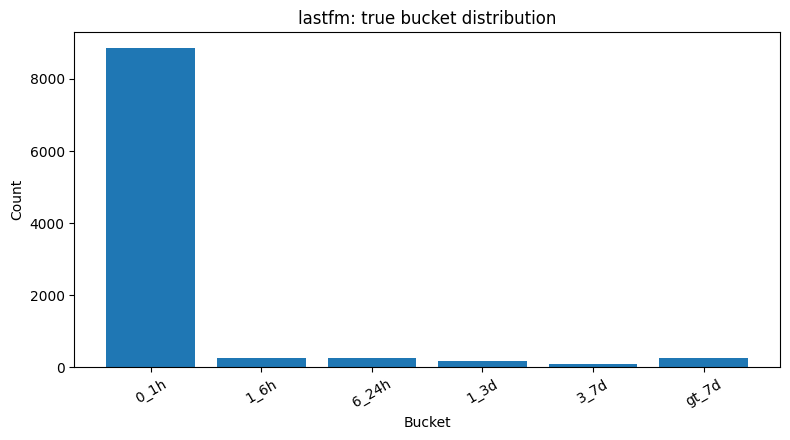

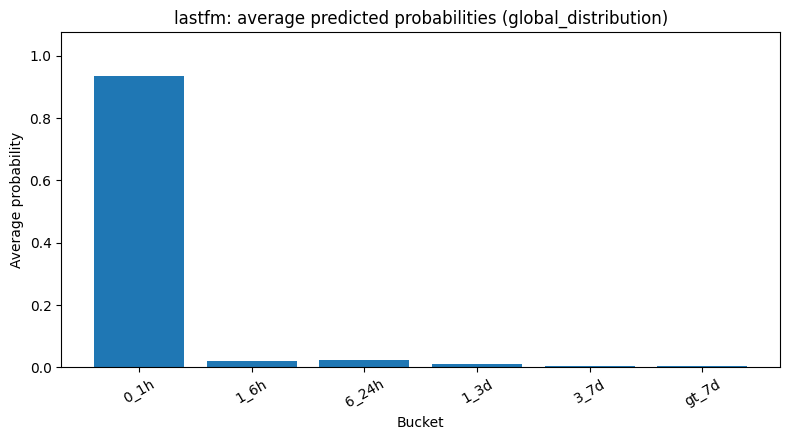

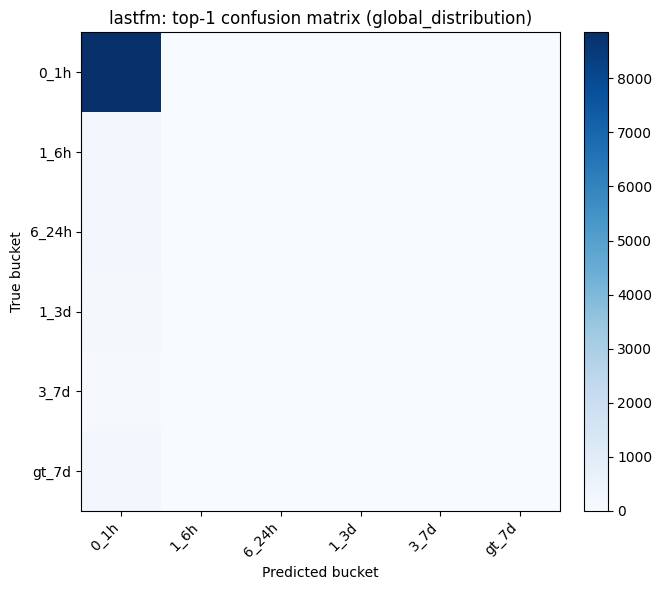

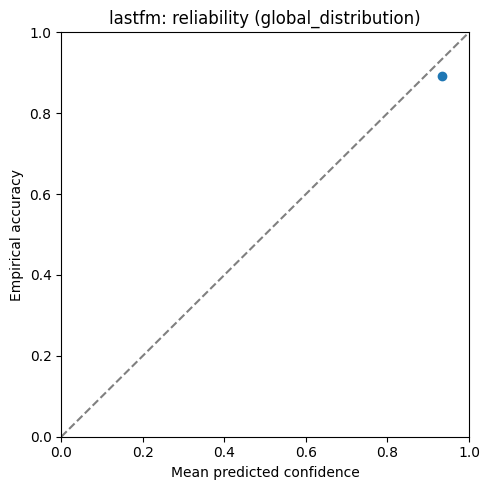

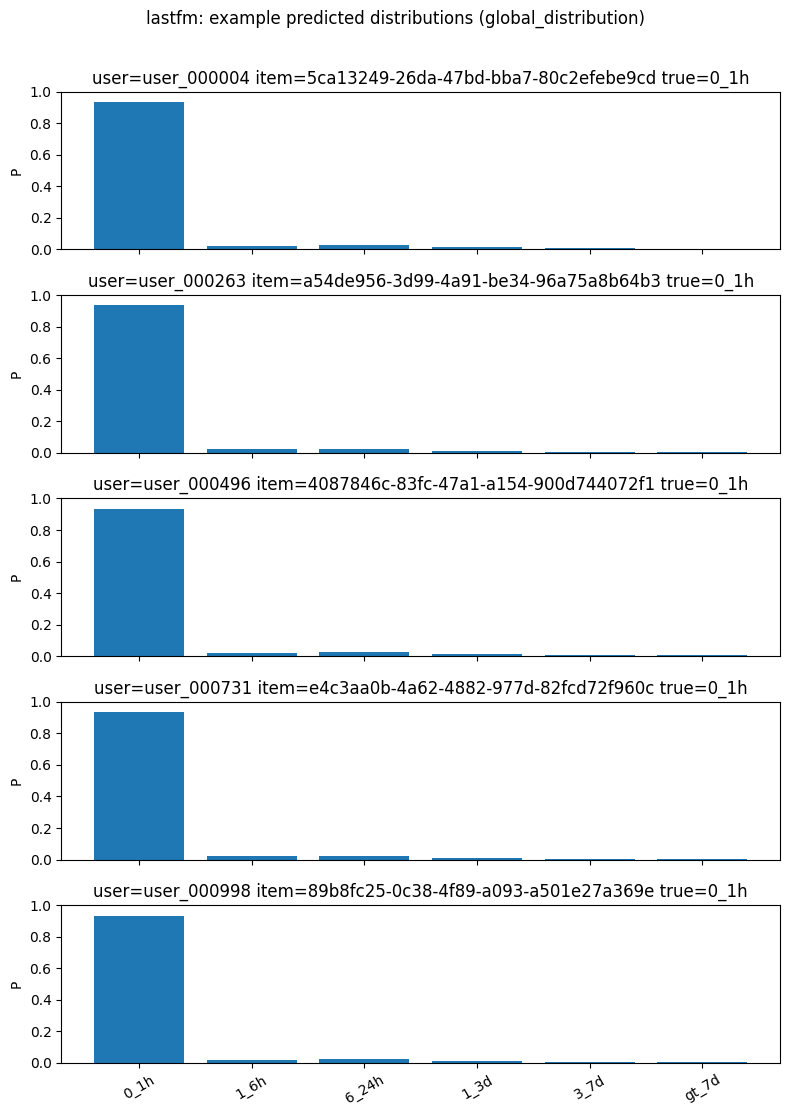

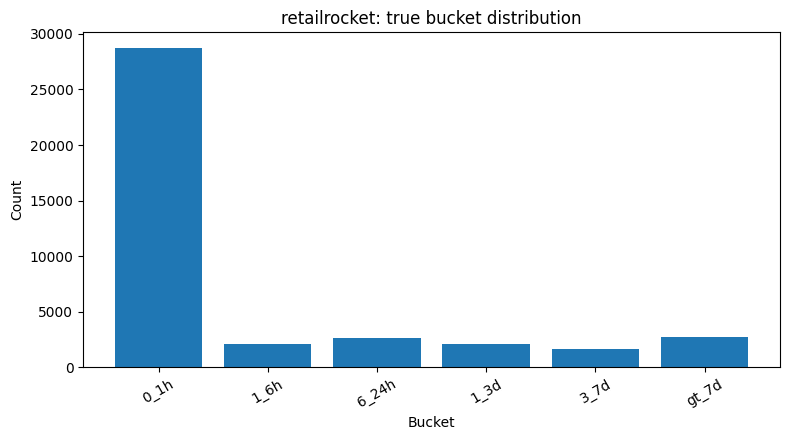

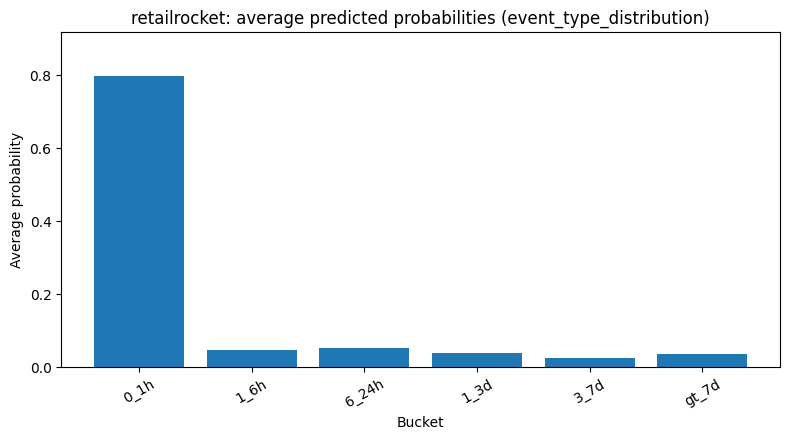

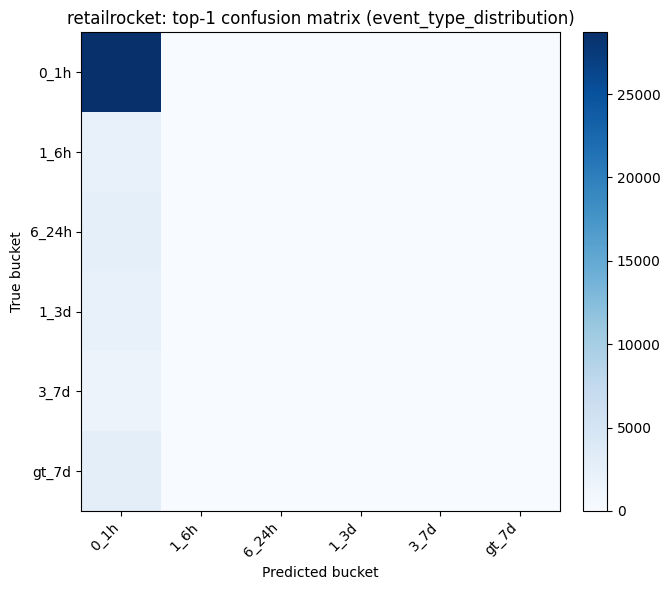

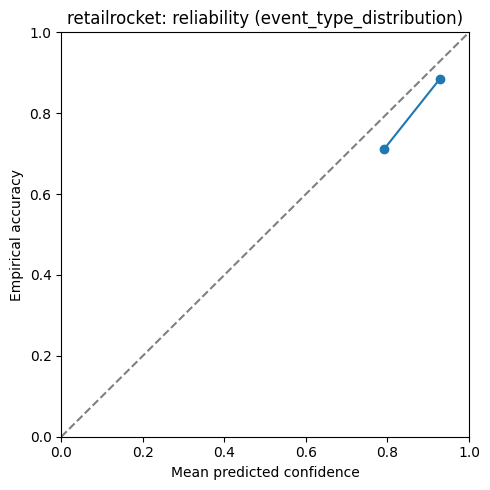

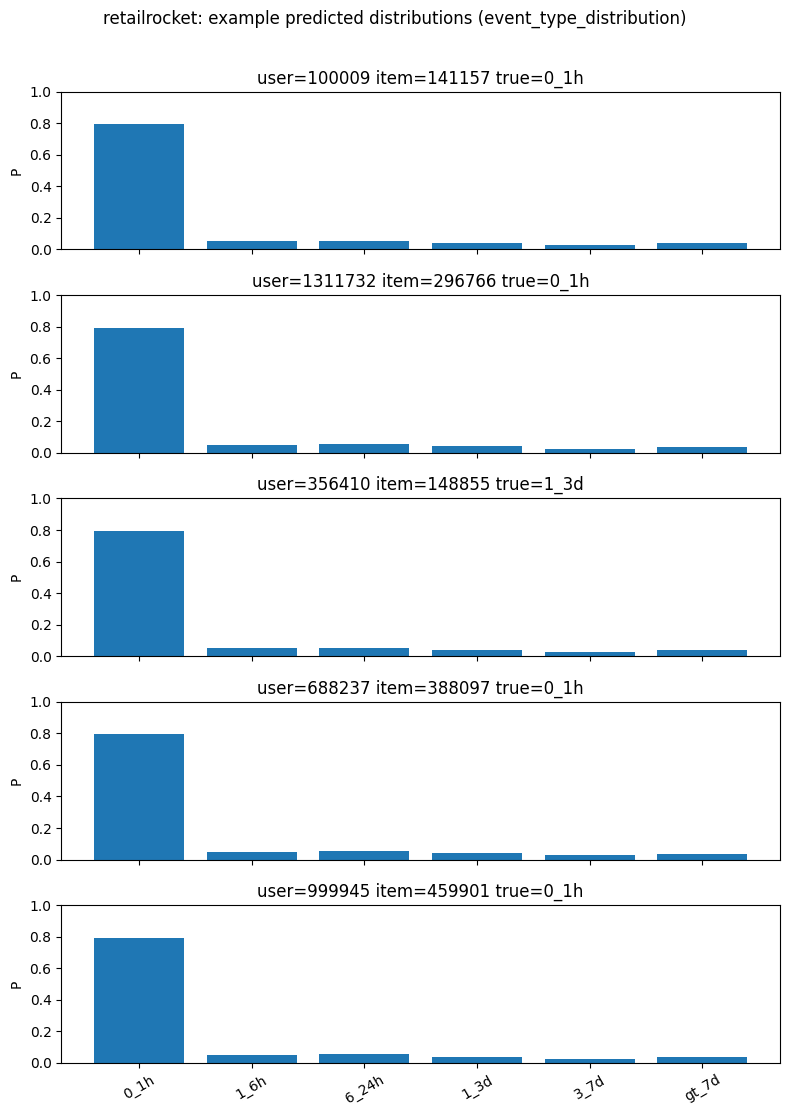

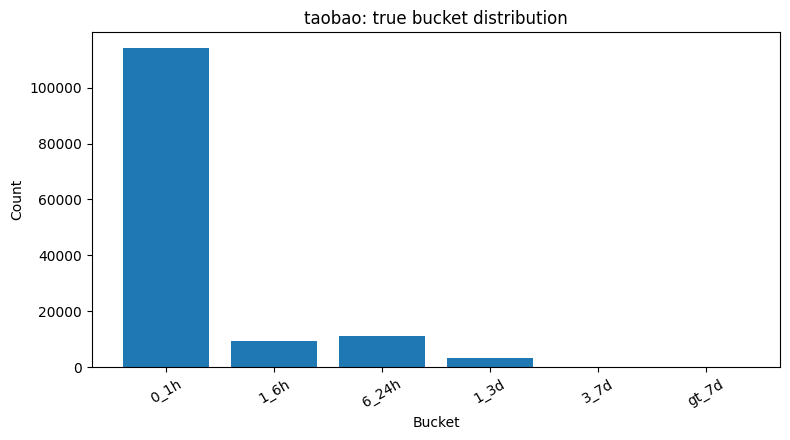

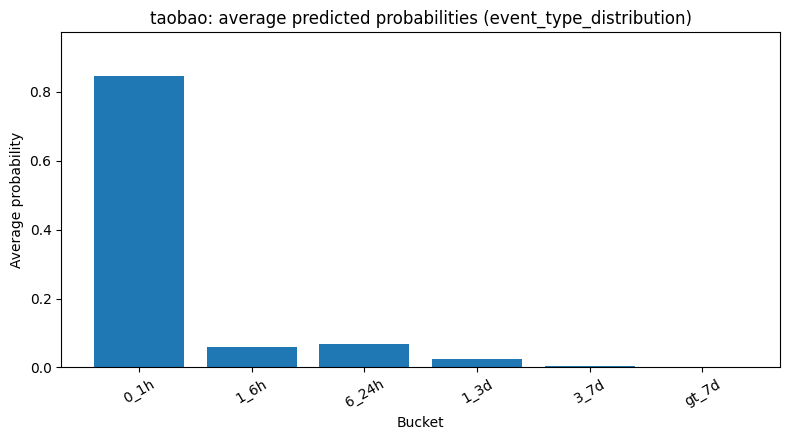

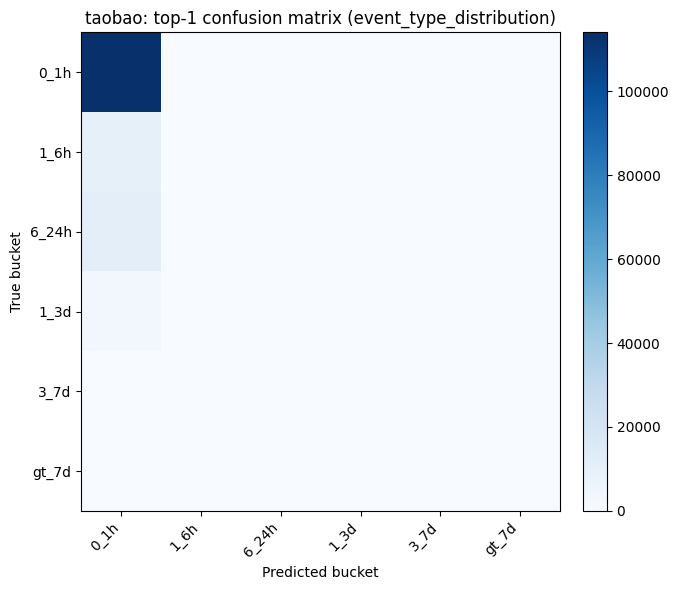

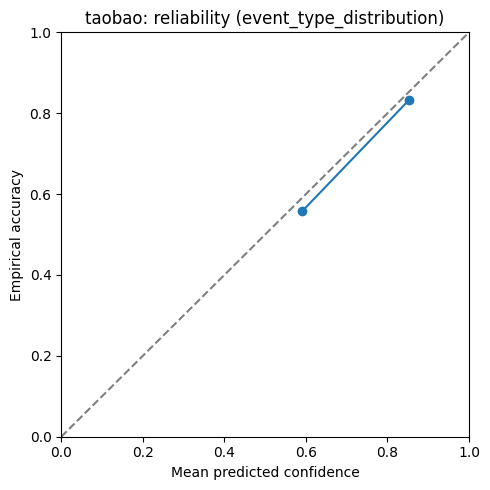

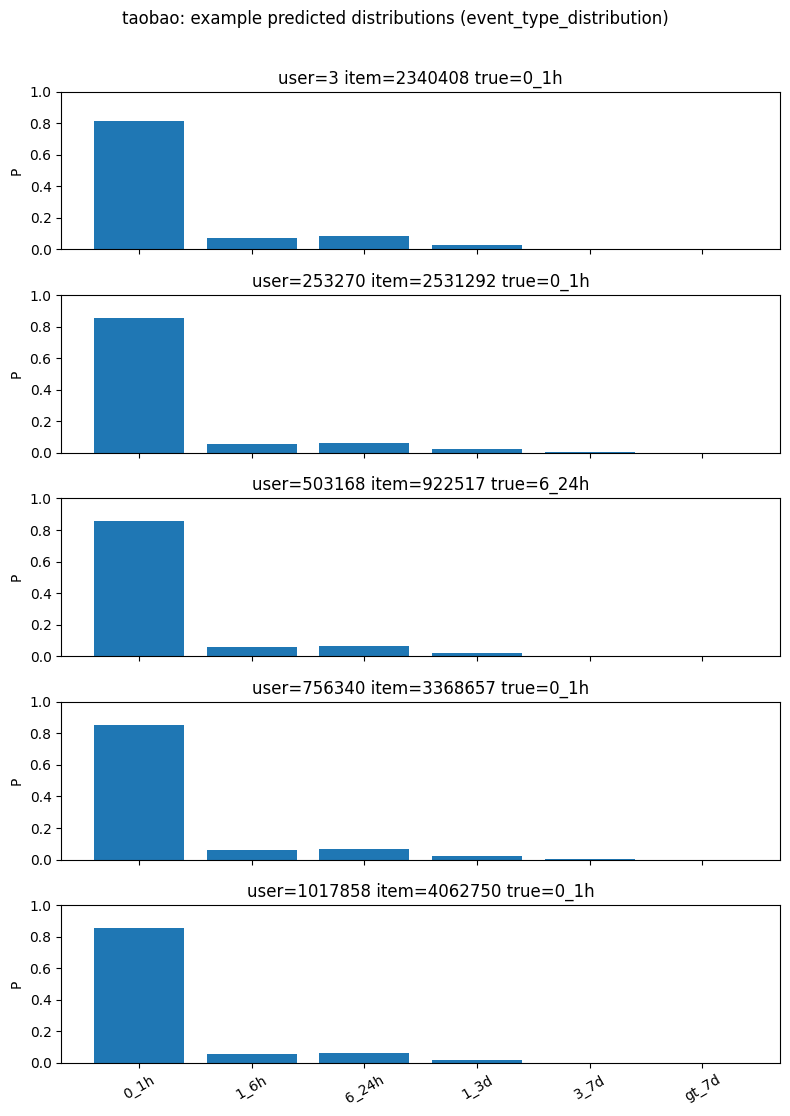

Saved figures:
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\lastfm_true_bucket_distribution.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\lastfm_global_distribution_avg_predicted_distribution.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\lastfm_global_distribution_confusion_matrix.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\lastfm_global_distribution_reliability.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\lastfm_global_distribution_example_predictions.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\retailrocket_true_bucket_distribution.png
y:\Recommender-System-Dashboard\outputs\next_time_probability_distribution\figures\retailrocket_event_type_distribution_avg_predicted_distribution.png
y:\Recommender-System-Dashboard\outputs\next_time_probabil

In [49]:
def best_model_for_dataset(results_df: pd.DataFrame, dataset: str) -> str:
    if "best_results" in globals() and not best_results[best_results["dataset"] == dataset].empty:
        return best_results[best_results["dataset"] == dataset].iloc[0]["model"]
    subset = results_df[results_df["dataset"] == dataset].sort_values(
        ["multiclass_log_loss", "mean_absolute_bucket_distance", "top_2_accuracy"],
        ascending=[True, True, False],
    )
    return subset.iloc[0]["model"]


def plot_true_distribution(dataset: str, test_df: pd.DataFrame) -> Path:
    counts = test_df["time_bucket_distribution"].value_counts(sort=False).reindex(BUCKET_LABELS, fill_value=0)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(BUCKET_LABELS, counts.to_numpy())
    ax.set_title(f"{dataset}: true bucket distribution")
    ax.set_xlabel("Bucket")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    path = FIGURE_DIR / f"{dataset}_true_bucket_distribution.png"
    fig.savefig(path, dpi=150)
    plt.show()
    return path


def plot_predicted_average_distribution(dataset: str, model_name: str, proba: np.ndarray) -> Path:
    avg_probs = proba.mean(axis=0)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(BUCKET_LABELS, avg_probs)
    ax.set_ylim(0, max(0.01, avg_probs.max() * 1.15))
    ax.set_title(f"{dataset}: average predicted probabilities ({model_name})")
    ax.set_xlabel("Bucket")
    ax.set_ylabel("Average probability")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    path = FIGURE_DIR / f"{dataset}_{model_name}_avg_predicted_distribution.png"
    fig.savefig(path, dpi=150)
    plt.show()
    return path


def plot_confusion_matrix(dataset: str, model_name: str, y_true: pd.Series, proba: np.ndarray) -> Path:
    pred_idx = np.argmax(proba, axis=1)
    y_pred = np.array(BUCKET_LABELS, dtype=object)[pred_idx]
    cm = confusion_matrix(y_true.astype(str), y_pred, labels=BUCKET_LABELS)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(np.arange(len(BUCKET_LABELS)), labels=BUCKET_LABELS, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(BUCKET_LABELS)), labels=BUCKET_LABELS)
    ax.set_xlabel("Predicted bucket")
    ax.set_ylabel("True bucket")
    ax.set_title(f"{dataset}: top-1 confusion matrix ({model_name})")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    path = FIGURE_DIR / f"{dataset}_{model_name}_confusion_matrix.png"
    fig.savefig(path, dpi=150)
    plt.show()
    return path


def plot_reliability(dataset: str, model_name: str, y_true: pd.Series, proba: np.ndarray, n_bins: int = 10) -> Path:
    pred_idx = np.argmax(proba, axis=1)
    confidence = proba.max(axis=1)
    true_idx = np.array([BUCKET_TO_INDEX[x] for x in y_true.astype(str)])
    correct = (pred_idx == true_idx).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    for left, right in zip(bins[:-1], bins[1:]):
        mask = (confidence >= left) & (confidence < right if right < 1 else confidence <= right)
        if mask.sum() == 0:
            continue
        rows.append({"confidence": confidence[mask].mean(), "accuracy": correct[mask].mean(), "count": int(mask.sum())})
    rel = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    if not rel.empty:
        ax.plot(rel["confidence"], rel["accuracy"], marker="o")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"{dataset}: reliability ({model_name})")
    fig.tight_layout()
    path = FIGURE_DIR / f"{dataset}_{model_name}_reliability.png"
    fig.savefig(path, dpi=150)
    plt.show()
    return path


def plot_example_predictions(dataset: str, model_name: str, test_df: pd.DataFrame, proba: np.ndarray, n_examples: int = 5) -> Path | None:
    n_examples = min(n_examples, len(test_df))
    if n_examples == 0:
        return None
    example_idx = np.linspace(0, len(test_df) - 1, n_examples, dtype=int)
    fig, axes = plt.subplots(n_examples, 1, figsize=(8, 2.2 * n_examples), sharex=True)
    if n_examples == 1:
        axes = [axes]
    for ax, row_idx in zip(axes, example_idx):
        row = test_df.iloc[row_idx]
        ax.bar(BUCKET_LABELS, proba[row_idx])
        ax.set_ylim(0, 1)
        ax.set_ylabel("P")
        ax.set_title(f"user={row['user_id']} item={row['item_id']} true={row['time_bucket_distribution']}")
    axes[-1].tick_params(axis="x", rotation=30)
    fig.suptitle(f"{dataset}: example predicted distributions ({model_name})", y=1.01)
    fig.tight_layout()
    path = FIGURE_DIR / f"{dataset}_{model_name}_example_predictions.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


figure_paths = []
for dataset, parts in prepared_data.items():
    if dataset not in model_probability_store or results_df[results_df["dataset"] == dataset].empty:
        continue
    best_model = best_model_for_dataset(results_df, dataset)
    proba = model_probability_store[dataset][best_model]
    test_df = parts["test"].reset_index(drop=True)
    y_true = test_df["time_bucket_distribution"]

    figure_paths.append(plot_true_distribution(dataset, test_df))
    figure_paths.append(plot_predicted_average_distribution(dataset, best_model, proba))
    figure_paths.append(plot_confusion_matrix(dataset, best_model, y_true, proba))
    figure_paths.append(plot_reliability(dataset, best_model, y_true, proba))
    example_path = plot_example_predictions(dataset, best_model, test_df, proba)
    if example_path is not None:
        figure_paths.append(example_path)

print("Saved figures:")
for path in figure_paths:
    print(path)


### Nhận xét các biểu đồ phân phối dự đoán

Các biểu đồ trên cho thấy các best model hiện tại chủ yếu học theo **phân phối prior** của dữ liệu, đặc biệt là bucket phổ biến `0_1h`. Ở cả ba dataset, true bucket distribution đều lệch mạnh về `0_1h`, và average predicted probabilities của best model cũng gán phần lớn xác suất cho bucket này.

Đối với **Last.fm**, best model là `global_distribution`. Phân phối dự đoán gần như cố định cho mọi sample, với xác suất rất cao cho bucket `0_1h`. Confusion matrix cho thấy model hầu như luôn dự đoán `0_1h`, nên các sample thuộc bucket khác đều bị kéo về bucket ngắn nhất. Điều này giải thích vì sao accuracy cao nhưng balanced accuracy và macro-F1 thấp. Reliability plot cho thấy xác suất dự đoán cho bucket chính khá gần với empirical accuracy, nhưng model không phân biệt được các bucket dài hơn.

Đối với **RetailRocket**, best model là `event_type_distribution`. So với Last.fm, phân phối thật của RetailRocket đa dạng hơn, nhưng model vẫn chủ yếu gán xác suất cao nhất cho `0_1h`. Confusion matrix cho thấy top-1 prediction gần như vẫn tập trung vào bucket này. Tuy vậy, event type giúp xác suất các bucket còn lại khác 0 và phản ánh được một phần prior theo loại hành vi. Reliability plot tương đối gần đường chéo, cho thấy xác suất của baseline này không quá lệch, nhưng khả năng phân biệt từng bucket vẫn còn hạn chế.

Đối với **Taobao**, best model cũng là `event_type_distribution`. True distribution lệch mạnh về `0_1h`, nhưng vẫn có một lượng đáng kể sample ở `1_6h` và `6_24h`. Average predicted probabilities có phản ánh điều này khi gán một phần xác suất cho các bucket trung bình. Tuy nhiên, confusion matrix vẫn cho thấy top-1 prediction gần như luôn là `0_1h`. Điều này cho thấy model có thể biểu diễn phân phối xác suất tổng thể khá tốt, nhưng chưa đủ mạnh để chọn đúng bucket top-1 cho các sample thuộc bucket thiểu số.

Các example predicted distributions cũng xác nhận xu hướng trên: với từng user-item cụ thể, phân phối dự đoán gần như giống nhau và luôn nghiêng mạnh về `0_1h`. Ngay cả khi true bucket là `1_3d` hoặc `6_24h`, model vẫn gán xác suất cao nhất cho `0_1h`. Vì vậy, các baseline hiện tại phù hợp để mô tả prior timing distribution, nhưng chưa đủ để cá nhân hóa thời điểm dự đoán theo từng user, item hoặc ngữ cảnh.

Nhìn chung, các biểu đồ cho thấy formulation dự đoán phân phối xác suất là hợp lý, nhưng bucket hiện tại còn quá thô ở vùng dưới 1 giờ. Vì `0_1h` chiếm đa số và làm model dễ dự đoán một bucket duy nhất, bước tiếp theo nên chia nhỏ vùng `<1h` thành các bucket như `0_1m`, `1_5m`, `5_15m`, `15_30m`, `30m_1h`. Điều này sẽ giúp kiểm tra liệu model có học được timing chi tiết hơn thay vì chỉ dự đoán rằng event tiếp theo sẽ xảy ra trong vòng một giờ.

## 11. Suy ra cumulative probabilities từ distribution output

Từ vector phân phối rời rạc, ta có thể suy ra xác suất tích lũy:

- `P(delta_t <= 1h) = P(0_1h)`
- `P(delta_t <= 6h) = P(0_1h) + P(1_6h)`
- `P(delta_t <= 24h) = P(0_1h) + P(1_6h) + P(6_24h)`
- `P(delta_t <= 3d) = previous + P(1_3d)`
- `P(delta_t <= 7d) = previous + P(3_7d)`

Điểm quan trọng là cumulative probabilities được suy ra từ một phân phối coherent trên các bucket loại trừ lẫn nhau. Vì vậy distribution modeling biểu cảm hơn các binary horizon models độc lập: tổng xác suất luôn được chuẩn hóa và các cửa sổ thời gian không mâu thuẫn với nhau.


In [50]:
probability_cols = [f"prob_{bucket}" for bucket in BUCKET_LABELS]
cumulative_cols = ["cum_within_1h", "cum_within_6h", "cum_within_24h", "cum_within_3d", "cum_within_7d"]
preview_cols = ["dataset", "model", "user_id", "item_id", "event_type", "timestamp", "true_bucket", "predicted_bucket"] + probability_cols + cumulative_cols

display(test_predictions_df[preview_cols].head(20))


,dataset,model,user_id,item_id,event_type,timestamp,true_bucket,predicted_bucket,prob_0_1h,prob_1_6h,prob_6_24h,prob_1_3d,prob_3_7d,prob_gt_7d,cum_within_1h,cum_within_6h,cum_within_24h,cum_within_3d,cum_within_7d
0,lastfm,global_distribution,user_000004,5ca13249-26da-47bd-bba7-80c2efebe9cd,listen,2009-04-09 12:49:50+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
1,lastfm,global_distribution,user_000004,<NA>,listen,2009-04-09 12:52:04+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
2,lastfm,global_distribution,user_000004,830d43d6-40cc-4199-85cc-f44f804a6de3,listen,2009-04-09 13:03:17+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
3,lastfm,global_distribution,user_000004,836b188d-06c2-4db2-94e9-386d47db50b7,listen,2009-04-09 13:09:01+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
4,lastfm,global_distribution,user_000004,<NA>,listen,2009-04-09 13:13:08+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
5,lastfm,global_distribution,user_000004,<NA>,listen,2009-04-09 13:47:15+00:00,gt_7d,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
6,lastfm,global_distribution,user_000004,fad1158a-08eb-4403-8edd-7ff2168f0a96,listen,2009-04-19 11:17:16+00:00,1_6h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
7,lastfm,global_distribution,user_000004,98452c25-d473-47ac-a195-f3376a2a67c7,listen,2009-04-19 13:04:26+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
8,lastfm,global_distribution,user_000004,25b2e350-37c5-4c8b-a3b2-d0d57259610e,listen,2009-04-19 13:09:46+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083
9,lastfm,global_distribution,user_000004,0476dc62-2b58-43fe-96b3-49b76ba17a08,listen,2009-04-19 13:14:06+00:00,0_1h,0_1h,0.934893,0.020282,0.024043,0.011595,0.00527,0.003917,0.934893,0.955175,0.979218,0.990814,0.996083


### Nhận xét về bảng dự đoán xác suất trên từng sample

Bảng trên hiển thị xác suất dự đoán của mô hình cho từng sample trong test set. Mỗi dòng tương ứng với một event hiện tại của user, bao gồm `user_id`, `item_id`, `event_type`, `timestamp`, bucket thật (`true_bucket`), bucket dự đoán (`predicted_bucket`) và phân phối xác suất trên các time bucket.

Đối với ví dụ Last.fm, mô hình tốt nhất là `global_distribution`, nên phân phối xác suất gần như giống nhau cho mọi dòng. Cụ thể, mô hình luôn gán xác suất rất cao cho bucket `0_1h`, khoảng 0.935. Điều này có nghĩa là theo prior chung của tập train, model tin rằng event tiếp theo có xác suất rất lớn xảy ra trong vòng một giờ.

Các cột `cum_within_*` là xác suất tích lũy được suy ra từ phân phối bucket. Ví dụ, `cum_within_1h = 0.934893` nghĩa là xác suất event xảy ra trong vòng 1 giờ là khoảng 93.5%. `cum_within_24h = 0.979218` nghĩa là xác suất event xảy ra trong vòng 24 giờ là khoảng 97.9%.

Tuy nhiên, vì đây là `global_distribution`, mô hình không cá nhân hóa theo user, item hay timestamp. Do đó, với những sample có `true_bucket = gt_7d` hoặc `true_bucket = 1_6h`, mô hình vẫn dự đoán `0_1h`. Điều này cho thấy baseline này bắt rất tốt xu hướng phổ biến của Last.fm, nhưng không phân biệt được các trường hợp có khoảng cách thời gian dài hơn.

Bảng này xác nhận lại kết luận từ confusion matrix và per-class metrics: mô hình baseline có accuracy cao vì phần lớn sample thật sự thuộc `0_1h`, nhưng chưa học được tín hiệu riêng để dự đoán các bucket ít phổ biến như `1_6h`, `1_3d`, `3_7d` hoặc `gt_7d`.

Nhìn chung, bảng dự đoán xác suất cho thấy formulation phân phối xác suất là diễn giải được, vì ta có thể đọc trực tiếp xác suất theo từng khoảng thời gian. Tuy nhiên, với baseline hiện tại, phân phối dự đoán vẫn chủ yếu phản ánh prior chung của dataset thay vì timing behavior riêng của từng user-item context.

## 12. Câu hỏi phân tích sau khi chạy notebook

Sau khi có kết quả đầy đủ, nên đọc notebook theo các câu hỏi sau:

1. Dataset nào có timing distribution rõ nhất? Dataset có một bucket thống trị sẽ dễ cho prior baseline nhưng chưa chắc dễ cho cá nhân hóa.
2. Bucket nào dễ hoặc khó dự đoán nhất? Xem per-class recall và confusion matrix.
3. ML có vượt global/user/item/event-type distribution baselines không? Nếu không, feature hiện tại có thể chưa đủ mạnh hoặc signal timing chủ yếu nằm ở prior.
4. Lỗi chủ yếu là near-neighbor bucket errors hay far bucket errors? `mean_absolute_bucket_distance` thấp cho thấy mô hình thường sai gần bucket thật.
5. Predicted distribution có hữu ích để chọn action trigger window không? Hữu ích khi xác suất tập trung vào một vài cửa sổ rõ ràng và calibration không quá lệch.
6. Điều này hỗ trợ action-conditioned event timing prediction như thế nào? Timing layer có thể nhận action/item đã được chọn từ module khác và ước lượng cửa sổ thời gian phù hợp để hành động.


## Trả lời các câu hỏi phân tích sau khi chạy notebook

### 1. Dataset nào có timing distribution rõ nhất?

Cả ba dataset đều có timing distribution khá rõ vì phần lớn sample tập trung vào bucket `0_1h`. Tuy nhiên, mỗi dataset có ý nghĩa khác nhau.

**Last.fm** có distribution rõ nhất theo nghĩa prior rất mạnh: phần lớn event tiếp theo xảy ra trong vòng một giờ. Điều này phản ánh hành vi nghe nhạc theo session, nơi các lượt nghe thường nối tiếp nhau trong thời gian ngắn. Vì vậy, `global_distribution` đã là baseline rất mạnh.

**RetailRocket** có distribution đa dạng hơn. Bucket `0_1h` vẫn chiếm đa số, nhưng các bucket dài hơn như `1_6h`, `6_24h`, `1_3d`, `3_7d`, `gt_7d` vẫn có tỷ lệ đáng kể hơn so với Last.fm. Vì vậy, RetailRocket phù hợp hơn để kiểm tra khả năng phân biệt nhiều khoảng thời gian khác nhau, dù dữ liệu user khá sparse.

**Taobao** nằm giữa hai trường hợp trên. Dataset này vẫn lệch mạnh về `0_1h`, nhưng có một lượng đáng kể sample ở `1_6h` và `6_24h`. Do đó, Taobao phù hợp để đánh giá short-to-medium timing hơn là long-gap timing.

Tóm lại, **Last.fm có prior timing rõ nhất**, **RetailRocket có phân phối đa dạng nhất**, còn **Taobao là dataset cân bằng hơn giữa số lượng user, độ dài lịch sử và short-to-medium timing signal**.

### 2. Bucket nào dễ hoặc khó dự đoán nhất?

Bucket dễ dự đoán nhất là **`0_1h`** ở cả ba dataset. Đây là bucket có support lớn nhất và cũng là bucket mà các baseline thường dự đoán top-1.

Các bucket khó dự đoán là các bucket ít xuất hiện như:

- `1_3d`
- `3_7d`
- `gt_7d`

Kết quả per-class cho thấy nhiều model có recall và F1 gần bằng 0 ở các bucket này. Điều đó có nghĩa là model gần như không chọn các bucket dài làm top-1 prediction, ngay cả khi bucket thật nằm ở đó.

Vì vậy, accuracy cao chủ yếu đến từ việc đoán đúng `0_1h`, chưa chứng minh rằng model dự đoán tốt toàn bộ phân phối thời gian.

### 3. ML có vượt global/user/item/event-type distribution baselines không?

Không. Trong kết quả hiện tại, **Logistic Regression không vượt được statistical baselines** ở cả ba dataset.

- Với **Last.fm**, `global_distribution` tốt hơn Logistic Regression.
- Với **RetailRocket**, `event_type_distribution` tốt hơn Logistic Regression.
- Với **Taobao**, `event_type_distribution` cũng tốt hơn Logistic Regression.

Điều này cho thấy các feature hiện tại chưa giúp mô hình học máy tạo ra phân phối xác suất tốt hơn các prior đơn giản. Timing signal hiện tại có thể đang nằm chủ yếu trong distribution prior của dataset hoặc trong `event_type`, thay vì trong các feature tabular mà Logistic Regression đang khai thác.

### 4. Lỗi chủ yếu là near-neighbor bucket errors hay far bucket errors?

Nhìn vào `mean_absolute_bucket_distance`, lỗi trung bình không quá lớn, đặc biệt với Last.fm và Taobao. Điều này xảy ra vì phần lớn sample thuộc `0_1h`, và model cũng thường dự đoán `0_1h`.

Tuy nhiên, confusion matrix và per-class results cho thấy một vấn đề khác: model gần như luôn dự đoán `0_1h`. Vì vậy, với các sample thật sự thuộc bucket xa như `3_7d` hoặc `gt_7d`, lỗi sẽ là **far bucket error**.

Nói cách khác:

- Xét trung bình toàn dataset, lỗi có vẻ nhỏ vì majority bucket chiếm quá lớn.
- Xét riêng các bucket thiểu số, lỗi có thể rất xa vì model kéo nhiều trường hợp về `0_1h`.

Do đó, `mean_absolute_bucket_distance` cần được đọc cùng với per-class recall và confusion matrix.

### 5. Predicted distribution có hữu ích để chọn action trigger window không?

Có hữu ích, nhưng hiện tại mới ở mức **prior-based trigger window**, chưa phải personalized timing mạnh.

Với các baseline tốt nhất, phân phối dự đoán thường tập trung mạnh vào `0_1h`. Điều này có thể hỗ trợ một quyết định đơn giản:

> Nếu chỉ dựa trên prior, action nên được kích hoạt trong khoảng rất gần sau event hiện tại.

Tuy nhiên, vì best model hiện tại thường dự đoán phân phối gần giống nhau cho nhiều sample, nó chưa cá nhân hóa tốt theo user, item hoặc context. Với những trường hợp true bucket là `6_24h`, `1_3d` hoặc `gt_7d`, model vẫn thường dự đoán `0_1h`.

Vì vậy, predicted distribution hiện tại hữu ích để xác định **default trigger window**, nhưng chưa đủ để quyết định timing cá nhân hóa cho từng user-item context.

### 6. Điều này hỗ trợ action-conditioned event timing prediction như thế nào?

Kết quả notebook hỗ trợ hướng **action-conditioned event timing prediction** ở mức formulation.

Thay vì dự đoán một timestamp duy nhất, mô hình trả về một phân phối xác suất:

```text
P(0_1h), P(1_6h), P(6_24h), P(1_3d), P(3_7d), P(gt_7d)
```

Cách output này phù hợp với timing layer trong recommender system, vì hệ thống có thể nhận một item/action đã được chọn từ module khác, sau đó ước lượng cửa sổ thời gian phù hợp để kích hoạt action.

Tuy nhiên, kết quả hiện tại cũng cho thấy baseline chủ yếu học prior distribution, chưa học được timing cá nhân hóa mạnh. Vì vậy, notebook này đóng vai trò là bước baseline quan trọng: nó chứng minh formulation probability distribution có thể triển khai được, đồng thời chỉ ra rằng các bước tiếp theo cần cải thiện model và representation.

Các hướng tiếp theo hợp lý gồm:

* chia nhỏ bucket dưới 1 giờ, ví dụ `0_1m`, `1_5m`, `5_15m`, `15_30m`, `30m_1h`;
* thêm item latent features thay vì dùng raw item id;
* xây dựng sequence/history features tốt hơn;
* thử class weighting hoặc calibration;
* chuyển sang discrete-time hazard modeling, survival analysis hoặc temporal point process.


## Kết luận

Notebook này kiểm tra formulation dự đoán phân phối xác suất cho next-time prediction. Thay vì dự đoán một timestamp hoặc một bucket duy nhất, mô hình trả về xác suất trên nhiều cửa sổ thời gian tương lai. Điều này phù hợp với action-conditioned event timing, nơi item/action đã được chọn trước và hệ thống cần xác định thời điểm kích hoạt có khả năng tạo event cao nhất.

Nếu mô hình học máy vượt được các statistical distribution baselines, điều đó cho thấy dữ liệu có tín hiệu timing học được từ context. Nếu không vượt được, kết quả vẫn có giá trị vì nó chỉ ra rằng prior distribution theo user/item/event_type đang chi phối mạnh, và bước tiếp theo cần feature tốt hơn hoặc mô hình time-to-event mạnh hơn như discrete-time hazard, survival analysis hoặc temporal point process.

Các ràng buộc quan trọng vẫn được giữ: không overwrite feasibility outputs, không dùng random split, aggregate probability features chỉ fit trên train, không dùng deep learning, và mọi dữ liệu derived được lưu dưới `outputs/next_time_probability_distribution/`.
